# Stop Signal & Working Memory: Exploratory Visualizations

Exploratory visualization notebook for prior-trial probe outcome analyses (Sections 1-14).

## Table of Contents
1. Probe Accuracy by Stop Signal Outcome
2. Does Prior-Trial Probe Outcome Predict Stop Success?
3. Prior-Trial Probe Outcome and Probe RT
4. Prior-Trial Probe Outcome and Go RT
5. Go RT Correct vs Incorrect by Prior-Trial Probe Outcome
6. SSD by Prior-Trial Probe Outcome
7. Prior-Trial Outcome and Go Accuracy
8. Does Prior Probe Outcome Predict Next Probe Outcome?
9. Does a Probe Omission on Trial t-1 Predict Stop Signal Success?
10. Does a Probe Omission on Trial t-1 Predict Go Omission?
11. Does a Probe Omission on Trial t-1 Predict Go RT?
12. Does a Probe Omission on Trial t-1 Predict SSD?
13. Does a Probe Omission on Trial t-1 Predict Next Probe Omission?
14. Does Prior-Trial Probe Commission Error Predict Stop Success? (Commission Only)
15. Does a Probe Omission on Trial t-1 Predict Probe RT?
16. Does a Probe Omission on Trial t-1 Predict Go Accuracy?
17. Does a Probe Omission on Trial t-1 Predict Next Probe Commission Rate?
18. Does Prior-Trial Probe Commission Error Predict Probe RT? (Commission Only)
19. Does Prior-Trial Probe Commission Error Predict Go RT? (Commission Only)
20. Does Prior-Trial Probe Commission Error Predict SSD? (Commission Only)
21. Does Prior-Trial Probe Commission Error Predict Go Accuracy? (Commission Only)
22. Does Prior-Trial Probe Commission Error Predict Go Omission Rate? (Commission Only)
23. Does Prior-Trial Probe Commission Error Predict Next Probe Omission Rate? (Commission Only)
24. Does Prior-Trial Probe Commission Error Predict Next Probe Commission Rate? (Commission Only)

In [1]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import f_oneway
import scipy.stats as stats

from stop_wm.config import ProjectConfig

# Initialize config with explicit project root
# Go up two levels from notebook location: data/figures/ -> project root
project_root = Path.cwd().parent
config = ProjectConfig(project_root=project_root)


# Pathing
trial_wise_data_wm_path = config.results_dir / 'post_qc_stop_signal_wm_trials.csv'
trial_wise_data_stop_path = config.results_dir / 'post_qc_stop_signal_trials.csv'
subject_wise_metrics_wm_path = config.results_dir / 'post_qc_stop_signal_wm_metrics.csv'
subject_wise_metrics_stop_path = config.results_dir / 'post_qc_stop_signal_metrics.csv'

# Load the data
trial_wise_data_wm = pd.read_csv(trial_wise_data_wm_path)
trial_wise_data_stop = pd.read_csv(trial_wise_data_stop_path)

# Load the metrics (subject-wise)
metrics_data_wm = pd.read_csv(subject_wise_metrics_wm_path)
metrics_data_stop = pd.read_csv(subject_wise_metrics_stop_path)



Key STOPWM_DATADIR not found in /Users/lyndefolsom/research/working_memory_inhibition/experiment_3/.env.


Key STOPWM_RAWDATADIR not found in /Users/lyndefolsom/research/working_memory_inhibition/experiment_3/.env.


## Setup. Within-Subject Confidence Interval Function

This function calculates within-subject confidence intervals using the Cousineau (2005) method with Morey (2008) correction. This is appropriate for repeated measures designs where we want to remove between-subject variability.

In [2]:
def calculate_within_subject_ci(data_matrix, confidence_level=0.95):
    """
    Calculate within-subject confidence intervals using Cousineau (2005) method
    with Morey (2008) correction.
    
    This method removes between-subject variability to show the precision
    of within-subject comparisons.
    
    Parameters:
    -----------
    data_matrix : DataFrame
        DataFrame with participants as rows, conditions as columns
    confidence_level : float
        Confidence level (default 0.95)
    
    Returns:
    --------
    ci_half_width : array
        Array of CI half-widths for each condition
    """
    from scipy import stats
    
    # Remove participants with missing data
    complete_data = data_matrix.dropna()
    
    if len(complete_data) == 0:
        return np.array([np.nan] * data_matrix.shape[1])
    
    # Step 1: Calculate participant means (remove between-subject variability)
    participant_means = complete_data.mean(axis=1)
    grand_mean = complete_data.values.mean()
    
    # Step 2: Center each participant's data around grand mean
    # This removes individual differences while preserving condition effects
    centered_data = complete_data.subtract(participant_means, axis=0) + grand_mean
    
    # Step 3: Calculate within-subject standard error for each condition
    n_participants = len(complete_data)
    n_conditions = complete_data.shape[1]
    
    # Calculate pooled within-subject variance
    condition_vars = centered_data.var(axis=0, ddof=1)
    
    # Standard error of the mean for within-subjects design
    within_subject_sem = np.sqrt(condition_vars / n_participants)
    
    # Apply Morey (2008) correction for within-subject CIs
    # Correction factor accounts for the number of conditions
    correction_factor = np.sqrt(n_conditions / (n_conditions - 1))
    corrected_sem = within_subject_sem * correction_factor
    
    # Calculate CI half-width using t-distribution
    t_critical = stats.t.ppf((1 + confidence_level) / 2, df=n_participants - 1)
    ci_half_width = t_critical * corrected_sem
    
    return ci_half_width



## 1. Probe Accuracy by Stop Signal Outcome

Visualization of probe accuracy conditional on stop signal outcome:
- **Successful Stop**: Trials where a stop signal was presented and the participant successfully inhibited their response
- **Failed Stop**: Trials where a stop signal was presented but the participant failed to inhibit
- **Go Trials**: Trials with no stop signal

This examines whether successful response inhibition is associated with better or worse memory performance.

**Statistical tests** (RM ANOVA + Bonferroni post-hoc) are in `analysis_notebook.ipynb`, Section 15.

> ⚠️ **Commission + omission errors are combined here.** The subject-level probe accuracy metric counts omission errors (no response) as incorrect alongside commission errors (wrong response). These are not distinguished in this section. See Sections 9–13 for omission-only analyses and Section 14 for commission-only.

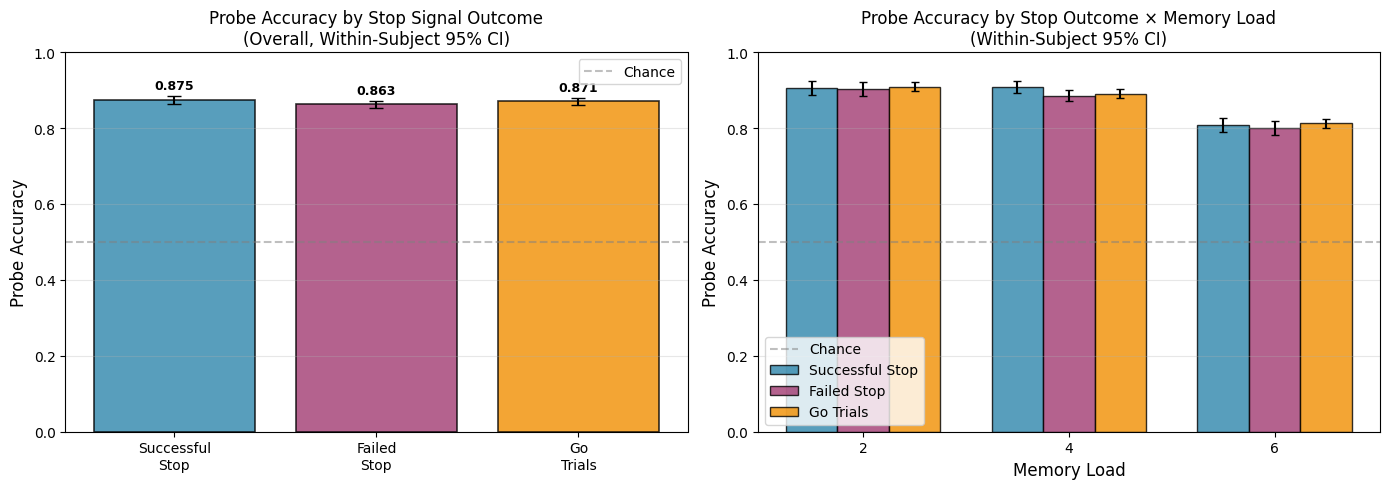


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [3]:
# === PROBE ACCURACY BY STOP SIGNAL OUTCOME — VISUALIZATION ===
# Statistical analysis (RM ANOVA + Bonferroni post-hoc) is in analysis_notebook.ipynb, Section 15.
metrics_data_wm = pd.read_csv('../data/results/post_qc_stop_signal_wm_metrics.csv')

wm_loads = [2, 4, 6]
results_by_load = {}
for wm_load in wm_loads:
    successful = metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_successful_stop'].dropna()
    failed = metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_failed_stop'].dropna()
    go = metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_go_trials'].dropna()
    results_by_load[wm_load] = {
        'successful': {'mean': successful.mean(), 'std': successful.std(), 'n': len(successful)},
        'failed': {'mean': failed.mean(), 'std': failed.std(), 'n': len(failed)},
        'go': {'mean': go.mean(), 'std': go.std(), 'n': len(go)}
    }

# Use the same color palette as the rest of the notebook
colors_outcome = ['#2E86AB', '#A23B72', '#F18F01']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall comparison (bar chart) with within-subject CIs
ax1 = axes[0]
conditions = ['Successful\nStop', 'Failed\nStop', 'Go\nTrials']

# Build within-subject CI for the overall plot
# Use only participants who have data for all three outcome types
overall_all_mask = (
    metrics_data_wm['probe_accuracy_on_successful_stop'].notna() &
    metrics_data_wm['probe_accuracy_on_failed_stop'].notna() &
    metrics_data_wm['probe_accuracy_on_go_trials'].notna()
)
overall_sub = metrics_data_wm.loc[overall_all_mask]
overall_matrix = pd.DataFrame({
    'Successful_Stop': overall_sub['probe_accuracy_on_successful_stop'].values,
    'Failed_Stop':     overall_sub['probe_accuracy_on_failed_stop'].values,
    'Go_Trials':       overall_sub['probe_accuracy_on_go_trials'].values,
})
overall_ws_cis = calculate_within_subject_ci(overall_matrix)
means = [overall_matrix.iloc[:, c].mean() for c in range(3)]
cis   = [overall_ws_cis.iloc[c] if hasattr(overall_ws_cis, 'iloc') else overall_ws_cis[c] for c in range(3)]

bars = ax1.bar(conditions, means, yerr=cis, capsize=5, color=colors_outcome, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Probe Accuracy', fontsize=12)
ax1.set_title('Probe Accuracy by Stop Signal Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, mean, ci in zip(bars, means, cis):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., height + ci + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: By WM load (grouped bar chart) with within-subject CIs
ax2 = axes[1]
x = np.arange(len(wm_loads))
width = 0.25

successful_means = [results_by_load[wm]['successful']['mean'] for wm in wm_loads]
failed_means = [results_by_load[wm]['failed']['mean'] for wm in wm_loads]
go_means = [results_by_load[wm]['go']['mean'] for wm in wm_loads]

# Calculate within-subject CIs for each WM load level
load_cis = {'successful': [], 'failed': [], 'go': []}
for wm_load in wm_loads:
    load_mask = (
        metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_successful_stop'].notna() &
        metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_failed_stop'].notna() &
        metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_go_trials'].notna()
    )
    load_sub = metrics_data_wm.loc[load_mask]
    load_matrix = pd.DataFrame({
        'Successful_Stop': load_sub[f'probe_wm{wm_load}_accuracy_on_successful_stop'].values,
        'Failed_Stop':     load_sub[f'probe_wm{wm_load}_accuracy_on_failed_stop'].values,
        'Go_Trials':       load_sub[f'probe_wm{wm_load}_accuracy_on_go_trials'].values,
    })
    ws_ci = calculate_within_subject_ci(load_matrix)
    load_cis['successful'].append(ws_ci.iloc[0] if hasattr(ws_ci, 'iloc') else ws_ci[0])
    load_cis['failed'].append(ws_ci.iloc[1] if hasattr(ws_ci, 'iloc') else ws_ci[1])
    load_cis['go'].append(ws_ci.iloc[2] if hasattr(ws_ci, 'iloc') else ws_ci[2])

bars1 = ax2.bar(x - width, successful_means, width, yerr=load_cis['successful'], capsize=3, 
                label='Successful Stop', color=colors_outcome[0], alpha=0.8,
                edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
bars2 = ax2.bar(x, failed_means, width, yerr=load_cis['failed'], capsize=3,
                label='Failed Stop', color=colors_outcome[1], alpha=0.8,
                edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
bars3 = ax2.bar(x + width, go_means, width, yerr=load_cis['go'], capsize=3,
                label='Go Trials', color=colors_outcome[2], alpha=0.8,
                edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})

ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Probe Accuracy', fontsize=12)
ax2.set_title('Probe Accuracy by Stop Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 2. Does Prior-Trial Probe Outcome Predict Stop Success?

Sequential dependency analysis: does the memory probe outcome on trial t-1 (correct vs. incorrect) predict whether the participant successfully inhibits on a stop trial at trial t?

- **t-1 Probe Correct → Stop trial**: stop success rate
- **t-1 Probe Incorrect → Stop trial**: stop success rate

Only consecutive trials *within the same block* are considered (no cross-block lag). Trial counts are reported because the conditions are likely unbalanced (most probes are correct).

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 9–13 for omission-only analyses and Section 14 for commission-only.

DOES PRIOR-TRIAL PROBE OUTCOME (t-1) PREDICT STOP SUCCESS?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 50

After t-1 Probe CORRECT:
  Stop success rate: M = 0.535, SD = 0.039
  Avg stop trials per subject: 120.9  (range: 84-139)
  Total stop trials: 6047

After t-1 Probe INCORRECT:
  Stop success rate: M = 0.550, SD = 0.140
  Avg stop trials per subject: 19.2  (range: 2-56)
  Total stop trials: 962

Paired t-test: t(49) = -0.673, p = 0.5044, Cohen's d = -0.096
  ΔBIC = -3.45, BF₁₀ = 0.18

--- t-1 Probe Incorrect trials per participant (Section 2: stop trials) ---
                          t-1_probe_incorrect_trials
participant_id                                      
69dc3f304137e723662d1a94                          56
6750f7eb7c60e2b2c22aeaea                          49
69dc0bb705c5528e019815eb                          48
69e129bd8ad451d4d82ff01f                          42
668e88ea6a476e76e0c1993b                          41
5f9fdfd04296cb01025

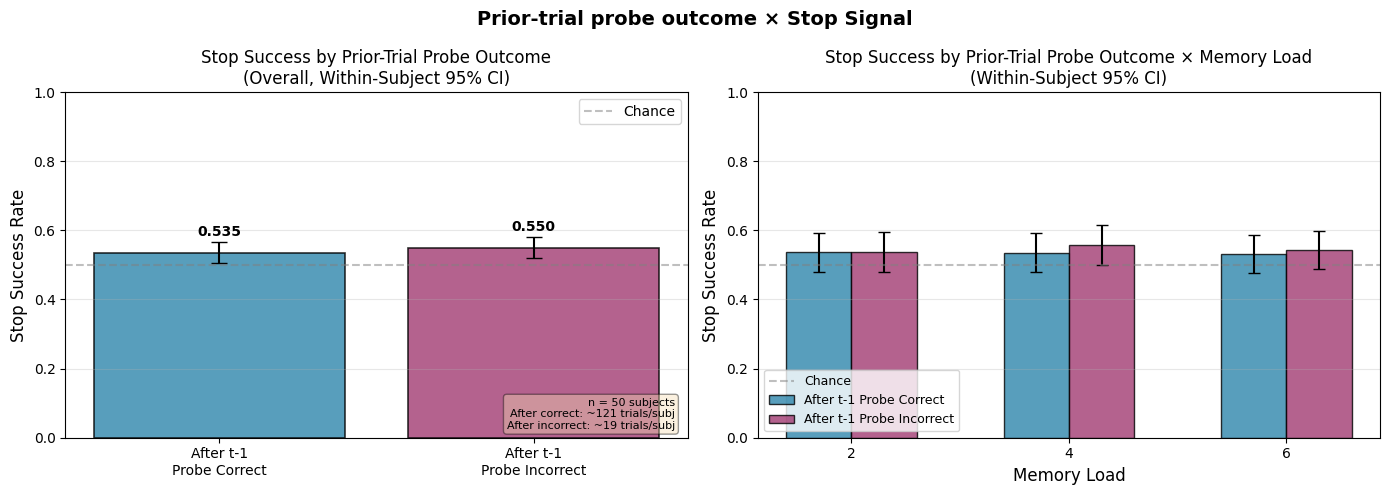


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).
Trial counts are likely unbalanced because most probes are answered correctly.


In [4]:
# === DOES PRIOR-TRIAL PROBE OUTCOME PREDICT STOP SUCCESS? ===
from scipy.stats import ttest_rel

trial_data = trial_wise_data_wm.copy()

trial_data = trial_data.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

# Lag the probe accuracy within each subject × block
trial_data['prev_probe_correct'] = (
    trial_data
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

# Determine stop success: on stop trials, correct_trial == 1 means successful inhibition
trial_data['is_stop'] = (trial_data['stop_trial_SS_trial_type'] == 'stop')
trial_data['stop_success'] = (
    trial_data['is_stop'] & (trial_data['stop_trial_correct_trial'] == 1)
).astype(float)

# Keep only stop trials that have a valid previous-trial probe outcome
stop_with_lag = trial_data.loc[
    trial_data['is_stop'] & trial_data['prev_probe_correct'].notna()
].copy()

print("=" * 70)
print("DOES PRIOR-TRIAL PROBE OUTCOME (t-1) PREDICT STOP SUCCESS?")
print("=" * 70)

# --- Overall (collapsed across WM load) ---
print("\n--- OVERALL (collapsed across WM load) ---\n")

# Per-subject stop success rate by previous-trial probe outcome
subj_stats = (
    stop_with_lag
    .groupby(['participant_id', 'prev_probe_correct'])
    .agg(
        stop_success_rate=('stop_success', 'mean'),
        n_trials=('stop_success', 'count'),
    )
    .reset_index()
)

after_correct = subj_stats.loc[subj_stats['prev_probe_correct'] == 1].set_index('participant_id')
after_incorrect = subj_stats.loc[subj_stats['prev_probe_correct'] == 0].set_index('participant_id')

# Only keep subjects who have data in BOTH conditions
common_subjs = after_correct.index.intersection(after_incorrect.index)
ac = after_correct.loc[common_subjs]
ai = after_incorrect.loc[common_subjs]

n_subj = len(common_subjs)
print(f"Subjects with data in both conditions: {n_subj}")
print(f"\nAfter t-1 Probe CORRECT:")
print(f"  Stop success rate: M = {ac['stop_success_rate'].mean():.3f}, SD = {ac['stop_success_rate'].std():.3f}")
print(f"  Avg stop trials per subject: {ac['n_trials'].mean():.1f}  (range: {ac['n_trials'].min()}-{ac['n_trials'].max()})")
print(f"  Total stop trials: {ac['n_trials'].sum()}")

print(f"\nAfter t-1 Probe INCORRECT:")
print(f"  Stop success rate: M = {ai['stop_success_rate'].mean():.3f}, SD = {ai['stop_success_rate'].std():.3f}")
print(f"  Avg stop trials per subject: {ai['n_trials'].mean():.1f}  (range: {ai['n_trials'].min()}-{ai['n_trials'].max()})")
print(f"  Total stop trials: {ai['n_trials'].sum()}")

# Paired t-test
t_val, p_val = ttest_rel(ac['stop_success_rate'], ai['stop_success_rate'])
diff = ac['stop_success_rate'].values - ai['stop_success_rate'].values
cohens_d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_subj - 1}) = {t_val:.3f}, p = {p_val:.4f}, Cohen's d = {cohens_d:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_subj) * np.log(1 + t_val**2 / ((n_subj) - 1)) - np.log(n_subj)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
# Per-participant t-1 probe incorrect trial counts (Section 2: stop trials)
print("\n--- t-1 Probe Incorrect trials per participant (Section 2: stop trials) ---")
ai_n = ai[['n_trials']].copy()
ai_n.columns = ['t-1_probe_incorrect_trials']
print(ai_n.sort_values('t-1_probe_incorrect_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_lag = [2, 4, 6]
results_by_load_lag = {}

for wm_load in wm_loads_lag:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = stop_with_lag.loc[stop_with_lag['memory_trial_stimLength'] == wm_load]

    load_subj_stats = (
        load_data
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(stop_success_rate=('stop_success', 'mean'), n_trials=('stop_success', 'count'))
        .reset_index()
    )
    lac = load_subj_stats.loc[load_subj_stats['prev_probe_correct'] == 1].set_index('participant_id')
    lai = load_subj_stats.loc[load_subj_stats['prev_probe_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]

    results_by_load_lag[wm_load] = {
        'after_correct':   {'mean': lac_c['stop_success_rate'].mean(), 'std': lac_c['stop_success_rate'].std(), 'n': len(lc), 'avg_trials': lac_c['n_trials'].mean()},
        'after_incorrect': {'mean': lai_c['stop_success_rate'].mean(), 'std': lai_c['stop_success_rate'].std(), 'n': len(lc), 'avg_trials': lai_c['n_trials'].mean()},
    }

    print(f"  Subjects with both conditions: {len(lc)}")
    print(f"  After t-1 Correct:   M = {lac_c['stop_success_rate'].mean():.3f}, SD = {lac_c['stop_success_rate'].std():.3f}, avg trials = {lac_c['n_trials'].mean():.1f}")
    print(f"  After t-1 Incorrect: M = {lai_c['stop_success_rate'].mean():.3f}, SD = {lai_c['stop_success_rate'].std():.3f}, avg trials = {lai_c['n_trials'].mean():.1f}")

    if len(lc) > 2:
        t_l, p_l = ttest_rel(lac_c['stop_success_rate'], lai_c['stop_success_rate'])
        d_l = (lac_c['stop_success_rate'].values - lai_c['stop_success_rate'].values)
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc)) * np.log(1 + t_l**2 / ((len(lc)) - 1)) - np.log(len(lc))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
    else:
        print("  Not enough subjects for paired t-test")

# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_lag = ['#2E86AB', '#A23B72']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe outcome × Stop Signal', fontsize=14, fontweight='bold')

# --- Plot 1: Overall ---
ax1 = axes[0]

overall_matrix_lag = pd.DataFrame({
    't-1 Correct':   ac['stop_success_rate'].values,
    't-1 Incorrect': ai['stop_success_rate'].values,
})
ws_ci_overall = calculate_within_subject_ci(overall_matrix_lag)
means_ov = [overall_matrix_lag.iloc[:, c].mean() for c in range(2)]
cis_ov = [ws_ci_overall.iloc[c] if hasattr(ws_ci_overall, 'iloc') else ws_ci_overall[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect']
bars = ax1.bar(cond_labels, means_ov, yerr=cis_ov, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Stop Success Rate', fontsize=12)
ax1.set_title('Stop Success by Prior-Trial Probe Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

for bar, mean, ci in zip(bars, means_ov, cis_ov):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., height + ci + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Trial count annotation
ax1.text(0.98, 0.02,
         f'n = {n_subj} subjects\n'
         f'After correct: ~{ac["n_trials"].mean():.0f} trials/subj\n'
         f'After incorrect: ~{ai["n_trials"].mean():.0f} trials/subj',
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# --- Plot 2: By WM Load ---
ax2 = axes[1]
x = np.arange(len(wm_loads_lag))
width = 0.3

correct_means = [results_by_load_lag[wm]['after_correct']['mean'] for wm in wm_loads_lag]
incorrect_means = [results_by_load_lag[wm]['after_incorrect']['mean'] for wm in wm_loads_lag]

load_cis_lag = {'correct': [], 'incorrect': []}
for wm_load in wm_loads_lag:
    r = results_by_load_lag[wm_load]
    load_data_wm = stop_with_lag.loc[stop_with_lag['memory_trial_stimLength'] == wm_load]
    load_subj_wm = (
        load_data_wm
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(stop_success_rate=('stop_success', 'mean'))
        .reset_index()
    )
    lac_wm = load_subj_wm.loc[load_subj_wm['prev_probe_correct'] == 1].set_index('participant_id')
    lai_wm = load_subj_wm.loc[load_subj_wm['prev_probe_correct'] == 0].set_index('participant_id')
    lc_wm = lac_wm.index.intersection(lai_wm.index)
    if len(lc_wm) > 2:
        wm_matrix = pd.DataFrame({
            'correct':   lac_wm.loc[lc_wm, 'stop_success_rate'].values,
            'incorrect': lai_wm.loc[lc_wm, 'stop_success_rate'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        load_cis_lag['correct'].append(ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0])
        load_cis_lag['incorrect'].append(ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1])
    else:
        load_cis_lag['correct'].append(0)
        load_cis_lag['incorrect'].append(0)

bars1 = ax2.bar(x - width/2, correct_means, width, yerr=load_cis_lag['correct'], capsize=4,
                label='After t-1 Probe Correct', color=colors_lag[0], alpha=0.8,
                edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
bars2 = ax2.bar(x + width/2, incorrect_means, width, yerr=load_cis_lag['incorrect'], capsize=4,
                label='After t-1 Probe Incorrect', color=colors_lag[1], alpha=0.8,
                edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})

ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Stop Success Rate', fontsize=12)
ax2.set_title('Stop Success by Prior-Trial Probe Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")
print("Trial counts are likely unbalanced because most probes are answered correctly.")

## 3. Prior-Trial Probe Outcome and Probe RT

Sequential dependency: does the memory probe outcome on trial t-1 (correct vs. incorrect) predict **probe RT** on trial t?

- **t-1 Probe Correct → trial t**: mean probe RT
- **t-1 Probe Incorrect → trial t**: mean probe RT

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 9–13 for omission-only analyses and Section 14 for commission-only.

Overall: Paired t-test: t(49) = -0.874, p = 0.3866, Cohen's d = -0.125
  ΔBIC = -3.14, BF₁₀ = 0.21

By WM Load:
  WM Load 2: Paired t-test: t(48) = -1.115, p = 0.2702, Cohen's d = -0.161
  ΔBIC = -2.64, BF₁₀ = 0.27
  WM Load 4: Paired t-test: t(49) = -0.731, p = 0.4685, Cohen's d = -0.104
  ΔBIC = -3.37, BF₁₀ = 0.19
  WM Load 6: Paired t-test: t(49) = -0.188, p = 0.8518, Cohen's d = -0.027
  ΔBIC = -3.88, BF₁₀ = 0.14


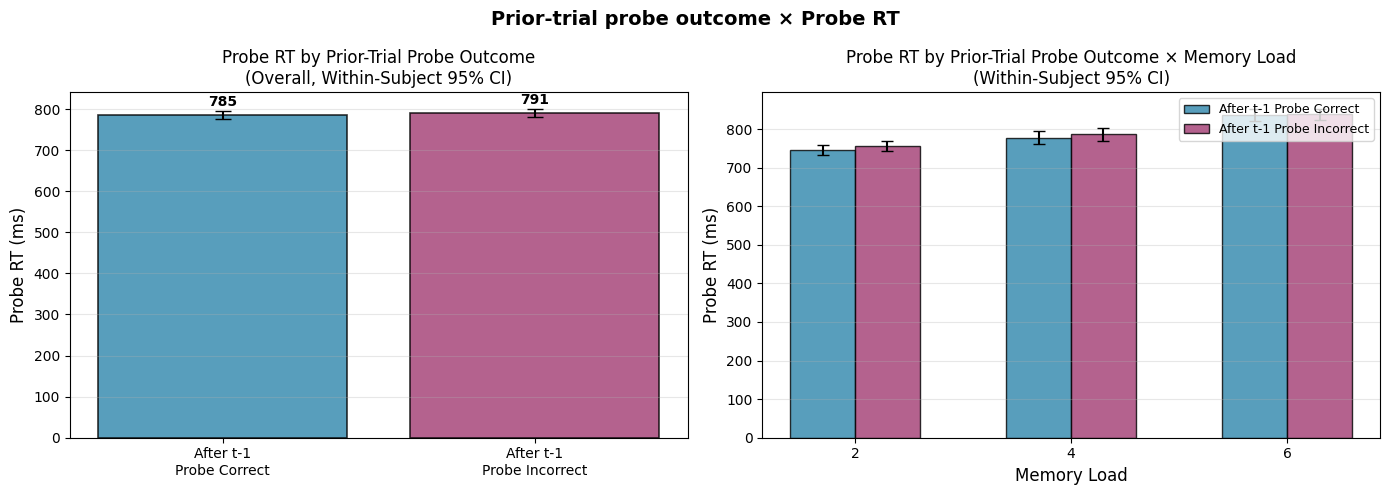


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [5]:
# === PRIOR-TRIAL PROBE OUTCOME AND PROBE RT ===
from scipy.stats import ttest_rel

trial_data_pr = trial_wise_data_wm.copy()
trial_data_pr = trial_data_pr.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_pr['prev_probe_correct'] = (
    trial_data_pr
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

probe_rt_with_lag = trial_data_pr.loc[
    trial_data_pr['prev_probe_correct'].notna() & trial_data_pr['memory_recognition_rt'].notna()
].copy()

# Per-subject mean probe RT by previous-trial probe outcome
subj_prt = (
    probe_rt_with_lag
    .groupby(['participant_id', 'prev_probe_correct'])
    .agg(mean_probe_rt=('memory_recognition_rt', 'mean'), n_trials=('memory_recognition_rt', 'count'))
    .reset_index()
)

prt_after_correct = subj_prt.loc[subj_prt['prev_probe_correct'] == 1].set_index('participant_id')
prt_after_incorrect = subj_prt.loc[subj_prt['prev_probe_correct'] == 0].set_index('participant_id')
common_subjs_prt = prt_after_correct.index.intersection(prt_after_incorrect.index)
pac = prt_after_correct.loc[common_subjs_prt]
pai = prt_after_incorrect.loc[common_subjs_prt]

# Overall matrix for within-subject CI
overall_matrix_prt = pd.DataFrame({
    't-1 Correct': pac['mean_probe_rt'].values,
    't-1 Incorrect': pai['mean_probe_rt'].values,
})
ws_ci_prt = calculate_within_subject_ci(overall_matrix_prt)
means_prt = [overall_matrix_prt.iloc[:, c].mean() for c in range(2)]
cis_prt = [ws_ci_prt.iloc[c] if hasattr(ws_ci_prt, 'iloc') else ws_ci_prt[c] for c in range(2)]

# Paired t-test (overall)
n_prt = len(common_subjs_prt)
t_prt, p_prt = ttest_rel(pac['mean_probe_rt'], pai['mean_probe_rt'])
diff_prt = pac['mean_probe_rt'].values - pai['mean_probe_rt'].values
cd_prt = diff_prt.mean() / diff_prt.std() if diff_prt.std() > 0 else np.nan
print(f"Overall: Paired t-test: t({n_prt - 1}) = {t_prt:.3f}, p = {p_prt:.4f}, Cohen's d = {cd_prt:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_prt) * np.log(1 + t_prt**2 / ((n_prt) - 1)) - np.log(n_prt)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\nBy WM Load:")
# By WM load
wm_loads_prt = [2, 4, 6]
results_by_load_prt = {}
for wm_load in wm_loads_prt:
    load_data = probe_rt_with_lag.loc[probe_rt_with_lag['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(mean_probe_rt=('memory_recognition_rt', 'mean'), n_trials=('memory_recognition_rt', 'count'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]
    if len(lc) > 2:
        t_l, p_l = ttest_rel(lac_c['mean_probe_rt'], lai_c['mean_probe_rt'])
        d_l = lac_c['mean_probe_rt'].values - lai_c['mean_probe_rt'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  WM Load {wm_load}: Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc)) * np.log(1 + t_l**2 / ((len(lc)) - 1)) - np.log(len(lc))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'correct': lac.loc[lc, 'mean_probe_rt'].values,
            'incorrect': lai.loc[lc, 'mean_probe_rt'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_prt[wm_load] = {
            'after_correct': {'mean': lac.loc[lc, 'mean_probe_rt'].mean(), 'ci': ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]},
            'after_incorrect': {'mean': lai.loc[lc, 'mean_probe_rt'].mean(), 'ci': ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]},
        }
    else:
        results_by_load_prt[wm_load] = {
            'after_correct': {'mean': lac['mean_probe_rt'].mean(), 'ci': 0},
            'after_incorrect': {'mean': lai['mean_probe_rt'].mean(), 'ci': 0},
        }

colors_lag = ['#2E86AB', '#A23B72']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe outcome × Probe RT', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
cond_labels = ['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect']
bars = ax1.bar(cond_labels, means_prt, yerr=cis_prt, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Probe RT (ms)', fontsize=12)
ax1.set_title('Probe RT by Prior-Trial Probe Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_prt, cis_prt):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 5,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_prt))
width = 0.3
correct_means = [results_by_load_prt[wm]['after_correct']['mean'] for wm in wm_loads_prt]
incorrect_means = [results_by_load_prt[wm]['after_incorrect']['mean'] for wm in wm_loads_prt]
correct_cis = [results_by_load_prt[wm]['after_correct']['ci'] for wm in wm_loads_prt]
incorrect_cis = [results_by_load_prt[wm]['after_incorrect']['ci'] for wm in wm_loads_prt]

ax2.bar(x - width/2, correct_means, width, yerr=correct_cis, capsize=4,
        label='After t-1 Probe Correct', color=colors_lag[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, incorrect_means, width, yerr=incorrect_cis, capsize=4,
        label='After t-1 Probe Incorrect', color=colors_lag[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Probe RT (ms)', fontsize=12)
ax2.set_title('Probe RT by Prior-Trial Probe Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 4. Prior-Trial Probe Outcome and Go RT

Sequential dependency: does the memory probe outcome on trial t-1 (correct vs. incorrect) predict **go trial RT** on trial t?

- **t-1 Probe Correct → Go trial**: mean RT
- **t-1 Probe Incorrect → Go trial**: mean RT

Only consecutive trials *within the same block* are considered. Within-subject 95% CIs (Cousineau-Morey).

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 9–13 for omission-only analyses and Section 14 for commission-only.

Overall: Paired t-test: t(49) = -0.536, p = 0.5946, Cohen's d = -0.077
  ΔBIC = -3.62, BF₁₀ = 0.16

By WM Load:
  WM Load 2: Paired t-test: t(48) = -0.598, p = 0.5530, Cohen's d = -0.086
  ΔBIC = -3.53, BF₁₀ = 0.17
  WM Load 4: Paired t-test: t(49) = -0.832, p = 0.4096, Cohen's d = -0.119
  ΔBIC = -3.21, BF₁₀ = 0.20
  WM Load 6: Paired t-test: t(49) = 0.681, p = 0.4991, Cohen's d = 0.097
  ΔBIC = -3.44, BF₁₀ = 0.18


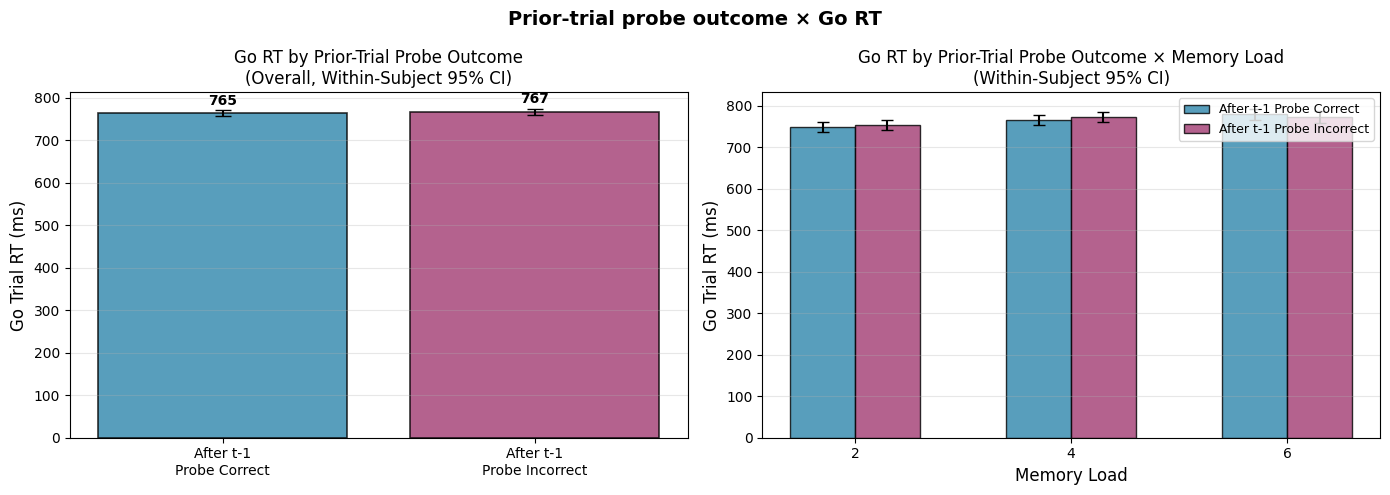


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [6]:
# === PRIOR-TRIAL PROBE OUTCOME AND GO RT ===
from scipy.stats import ttest_rel

trial_data = trial_wise_data_wm.copy()
trial_data = trial_data.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data['prev_probe_correct'] = (
    trial_data
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

trial_data['is_stop'] = trial_data['stop_trial_SS_trial_type'].str.lower() == 'stop'
trial_data['go_rt'] = trial_data['stop_trial_rt'].astype(float)

go_with_lag = trial_data.loc[
    (~trial_data['is_stop']) & trial_data['prev_probe_correct'].notna() & trial_data['go_rt'].notna()
].copy()

# Per-subject mean go RT by previous-trial probe outcome
subj_rt = (
    go_with_lag
    .groupby(['participant_id', 'prev_probe_correct'])
    .agg(mean_go_rt=('go_rt', 'mean'), n_trials=('go_rt', 'count'))
    .reset_index()
)

rt_after_correct = subj_rt.loc[subj_rt['prev_probe_correct'] == 1].set_index('participant_id')
rt_after_incorrect = subj_rt.loc[subj_rt['prev_probe_correct'] == 0].set_index('participant_id')
common_subjs_rt = rt_after_correct.index.intersection(rt_after_incorrect.index)
rac = rt_after_correct.loc[common_subjs_rt]
rai = rt_after_incorrect.loc[common_subjs_rt]

# Overall matrix for within-subject CI
overall_matrix_rt = pd.DataFrame({
    't-1 Correct': rac['mean_go_rt'].values,
    't-1 Incorrect': rai['mean_go_rt'].values,
})
ws_ci_rt = calculate_within_subject_ci(overall_matrix_rt)
means_rt = [overall_matrix_rt.iloc[:, c].mean() for c in range(2)]
cis_rt = [ws_ci_rt.iloc[c] if hasattr(ws_ci_rt, 'iloc') else ws_ci_rt[c] for c in range(2)]

# Paired t-test (overall)
n_rt = len(common_subjs_rt)
t_rt, p_rt = ttest_rel(rac['mean_go_rt'], rai['mean_go_rt'])
diff_rt = rac['mean_go_rt'].values - rai['mean_go_rt'].values
cd_rt = diff_rt.mean() / diff_rt.std() if diff_rt.std() > 0 else np.nan
print(f"Overall: Paired t-test: t({n_rt - 1}) = {t_rt:.3f}, p = {p_rt:.4f}, Cohen's d = {cd_rt:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_rt) * np.log(1 + t_rt**2 / ((n_rt) - 1)) - np.log(n_rt)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\nBy WM Load:")
# By WM load
wm_loads_rt = [2, 4, 6]
results_by_load_rt = {}
for wm_load in wm_loads_rt:
    load_data = go_with_lag.loc[go_with_lag['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(mean_go_rt=('go_rt', 'mean'), n_trials=('go_rt', 'count'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]
    if len(lc) > 2:
        t_l, p_l = ttest_rel(lac_c['mean_go_rt'], lai_c['mean_go_rt'])
        d_l = lac_c['mean_go_rt'].values - lai_c['mean_go_rt'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  WM Load {wm_load}: Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc)) * np.log(1 + t_l**2 / ((len(lc)) - 1)) - np.log(len(lc))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'correct': lac.loc[lc, 'mean_go_rt'].values,
            'incorrect': lai.loc[lc, 'mean_go_rt'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_rt[wm_load] = {
            'after_correct': {'mean': lac.loc[lc, 'mean_go_rt'].mean(), 'ci': ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]},
            'after_incorrect': {'mean': lai.loc[lc, 'mean_go_rt'].mean(), 'ci': ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]},
        }
    else:
        results_by_load_rt[wm_load] = {
            'after_correct': {'mean': lac['mean_go_rt'].mean(), 'ci': 0},
            'after_incorrect': {'mean': lai['mean_go_rt'].mean(), 'ci': 0},
        }

colors_lag = ['#2E86AB', '#A23B72']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe outcome × Go RT', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
cond_labels = ['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect']
bars = ax1.bar(cond_labels, means_rt, yerr=cis_rt, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Go Trial RT (ms)', fontsize=12)
ax1.set_title('Go RT by Prior-Trial Probe Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_rt, cis_rt):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 5,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_rt))
width = 0.3
correct_means = [results_by_load_rt[wm]['after_correct']['mean'] for wm in wm_loads_rt]
incorrect_means = [results_by_load_rt[wm]['after_incorrect']['mean'] for wm in wm_loads_rt]
correct_cis = [results_by_load_rt[wm]['after_correct']['ci'] for wm in wm_loads_rt]
incorrect_cis = [results_by_load_rt[wm]['after_incorrect']['ci'] for wm in wm_loads_rt]

ax2.bar(x - width/2, correct_means, width, yerr=correct_cis, capsize=4,
        label='After t-1 Probe Correct', color=colors_lag[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, incorrect_means, width, yerr=incorrect_cis, capsize=4,
        label='After t-1 Probe Incorrect', color=colors_lag[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Go Trial RT (ms)', fontsize=12)
ax2.set_title('Go RT by Prior-Trial Probe Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 5. Go RT Correct vs Incorrect by Prior-Trial Probe Outcome

Disambiguates section 17 by splitting Go RT into:
- **Go RT Correct**: mean RT on Go trials where the participant responded correctly (`stop_trial_correct_trial == 1`)
- **Go RT Incorrect**: mean RT on Go trials where the participant responded but was incorrect (commission errors; `stop_trial_correct_trial == 0`)

Each is analyzed by prior-trial probe outcome (t-1 correct vs t-1 incorrect). **Figure legend**: bar color = t-1 outcome; diagonal hatching = Go Incorrect.

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 9–13 for omission-only analyses and Section 14 for commission-only.

Go RT Correct: Paired t-test: t(2) = -0.308, p = 0.7591, Cohen's d = -0.044
  ΔBIC = -0.96, BF₁₀ = 0.62
Go RT Incorrect: Paired t-test: t(2) = 0.215, p = 0.8313, Cohen's d = 0.040
  ΔBIC = -1.03, BF₁₀ = 0.60


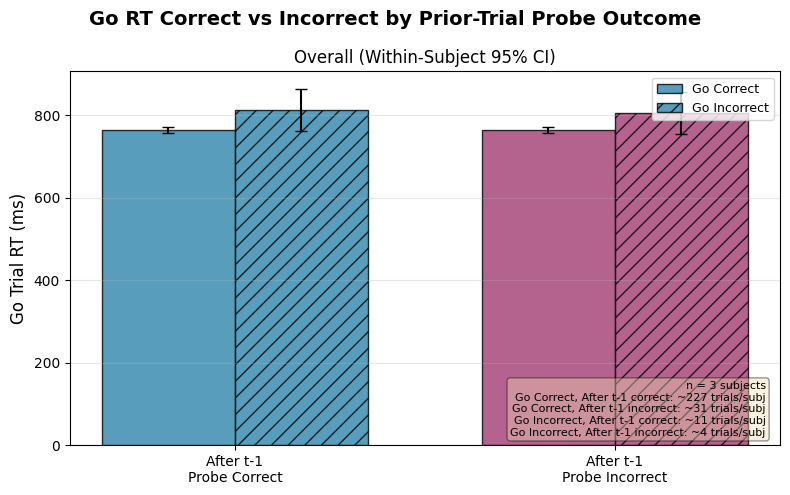


Note: Color = t-1 outcome; Hatching = Go Correct (solid) vs Go Incorrect (diagonal lines). Trial counts = avg per subject.


In [7]:
# === GO RT CORRECT vs INCORRECT BY PRIOR-TRIAL PROBE OUTCOME ===
from scipy.stats import ttest_rel

trial_data_17b = trial_wise_data_wm.copy()
trial_data_17b = trial_data_17b.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_17b['prev_probe_correct'] = (
    trial_data_17b
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

trial_data_17b['is_stop'] = trial_data_17b['stop_trial_SS_trial_type'].str.lower() == 'stop'
trial_data_17b['go_rt'] = trial_data_17b['stop_trial_rt'].astype(float)
trial_data_17b['go_correct'] = pd.to_numeric(trial_data_17b['stop_trial_correct_trial'], errors='coerce')

# Go trials with response, split by correctness
base_filter = (~trial_data_17b['is_stop']) & trial_data_17b['prev_probe_correct'].notna() & trial_data_17b['go_rt'].notna()
go_correct_trials = trial_data_17b.loc[base_filter & (trial_data_17b['go_correct'] == 1)].copy()
go_incorrect_trials = trial_data_17b.loc[base_filter & (trial_data_17b['go_correct'] == 0)].copy()

def run_go_rt_analysis(go_df, label):
    """Run prior-trial probe outcome analysis for a subset of go trials."""
    subj_rt = (
        go_df
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(mean_go_rt=('go_rt', 'mean'), n_trials=('go_rt', 'count'))
        .reset_index()
    )
    rt_after_correct = subj_rt.loc[subj_rt['prev_probe_correct'] == 1].set_index('participant_id')
    rt_after_incorrect = subj_rt.loc[subj_rt['prev_probe_correct'] == 0].set_index('participant_id')
    common = rt_after_correct.index.intersection(rt_after_incorrect.index)
    rac = rt_after_correct.loc[common]
    rai = rt_after_incorrect.loc[common]
    if len(common) < 3:
        return None, None, None, None, None, None, None
    overall_matrix = pd.DataFrame({'t-1 Correct': rac['mean_go_rt'].values, 't-1 Incorrect': rai['mean_go_rt'].values})
    ws_ci = calculate_within_subject_ci(overall_matrix)
    means = [overall_matrix.iloc[:, c].mean() for c in range(2)]
    cis = [ws_ci.iloc[c] if hasattr(ws_ci, 'iloc') else ws_ci[c] for c in range(2)]
    t_val, p_val = ttest_rel(rac['mean_go_rt'], rai['mean_go_rt'])
    diff = rac['mean_go_rt'].values - rai['mean_go_rt'].values
    cd = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    results_by_load = {}
    for wm_load in [2, 4, 6]:
        load_data = go_df.loc[go_df['memory_trial_stimLength'] == wm_load]
        load_subj = load_data.groupby(['participant_id', 'prev_probe_correct']).agg(mean_go_rt=('go_rt', 'mean')).reset_index()
        lac = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
        lai = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
        lc = lac.index.intersection(lai.index)
        if len(lc) > 2:
            wm_matrix = pd.DataFrame({'correct': lac.loc[lc, 'mean_go_rt'].values, 'incorrect': lai.loc[lc, 'mean_go_rt'].values})
            ws_ci_wm = calculate_within_subject_ci(wm_matrix)
            results_by_load[wm_load] = {
                'after_correct': {'mean': lac.loc[lc, 'mean_go_rt'].mean(), 'ci': ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]},
                'after_incorrect': {'mean': lai.loc[lc, 'mean_go_rt'].mean(), 'ci': ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]},
            }
        else:
            results_by_load[wm_load] = {'after_correct': {'mean': lac['mean_go_rt'].mean(), 'ci': 0}, 'after_incorrect': {'mean': lai['mean_go_rt'].mean(), 'ci': 0}}
    return means, cis, t_val, p_val, cd, results_by_load, common

# Run for correct and incorrect go trials
res_correct = run_go_rt_analysis(go_correct_trials, 'Go Correct')
res_incorrect = run_go_rt_analysis(go_incorrect_trials, 'Go Incorrect')

# Trial counts (avg per subject) for each of the 4 conditions (like Section 2)
subj_gc = go_correct_trials.groupby(['participant_id', 'prev_probe_correct']).size().reset_index(name='n_trials')
subj_gi = go_incorrect_trials.groupby(['participant_id', 'prev_probe_correct']).size().reset_index(name='n_trials')
n_gc_t1c = subj_gc[subj_gc['prev_probe_correct']==1]['n_trials'].mean()
n_gc_t1i = subj_gc[subj_gc['prev_probe_correct']==0]['n_trials'].mean()
n_gi_t1c = subj_gi[subj_gi['prev_probe_correct']==1]['n_trials'].mean()
n_gi_t1i = subj_gi[subj_gi['prev_probe_correct']==0]['n_trials'].mean()
n_subj_17b = len(res_correct[5]) if res_correct[5] is not None else 0

colors_17b = ['#2E86AB', '#A23B72']  # t-1 Correct, t-1 Incorrect
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle('Go RT Correct vs Incorrect by Prior-Trial Probe Outcome', fontsize=14, fontweight='bold')

# Overall: Color = t-1 outcome; Hatching = Go Correct (none) vs Go Incorrect (//)
x = np.arange(2)  # After t-1 Correct, After t-1 Incorrect
width = 0.35
if res_correct[0] is not None:
    ax.bar(x - width/2, res_correct[0], width, yerr=res_correct[1], capsize=4, label='Go Correct', color=colors_17b, alpha=0.8, edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
    print(f"Go RT Correct: Paired t-test: t({len(res_correct[5])-1}) = {res_correct[2]:.3f}, p = {res_correct[3]:.4f}, Cohen's d = {res_correct[4]:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = (len(res_correct[5])) * np.log(1 + res_correct[2]**2 / ((len(res_correct[5])) - 1)) - np.log(len(res_correct[5]))
    bf10 = np.exp(delta_bic / 2)
    print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
if res_incorrect[0] is not None:
    ax.bar(x + width/2, res_incorrect[0], width, yerr=res_incorrect[1], capsize=4, label='Go Incorrect', color=colors_17b, alpha=0.8, edgecolor='black', linewidth=1.0, hatch='//', error_kw={'linewidth': 1.5, 'ecolor': 'black'})
    print(f"Go RT Incorrect: Paired t-test: t({len(res_incorrect[5])-1}) = {res_incorrect[2]:.3f}, p = {res_incorrect[3]:.4f}, Cohen's d = {res_incorrect[4]:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = (len(res_incorrect[5])) * np.log(1 + res_incorrect[2]**2 / ((len(res_incorrect[5])) - 1)) - np.log(len(res_incorrect[5]))
    bf10 = np.exp(delta_bic / 2)
    print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
# Trial count annotation (like Section 2: corner text box)
ax.text(0.98, 0.02,
        f'n = {n_subj_17b} subjects\n'
        f'Go Correct, After t-1 correct: ~{n_gc_t1c:.0f} trials/subj\n'
        f'Go Correct, After t-1 incorrect: ~{n_gc_t1i:.0f} trials/subj\n'
        f'Go Incorrect, After t-1 correct: ~{n_gi_t1c:.0f} trials/subj\n'
        f'Go Incorrect, After t-1 incorrect: ~{n_gi_t1i:.0f} trials/subj',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

ax.set_xticks(x)
ax.set_xticklabels(['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect'])
ax.set_ylabel('Go Trial RT (ms)', fontsize=12)
ax.set_title('Overall (Within-Subject 95% CI)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Color = t-1 outcome; Hatching = Go Correct (solid) vs Go Incorrect (diagonal lines). Trial counts = avg per subject.")

## 6. SSD by Prior-Trial Probe Outcome

Sequential dependency: does the memory probe outcome on trial t-1 (correct vs. incorrect) predict **SSD** (stop-signal delay) on trial t?

- **t-1 Probe Correct → Stop trial**: mean SSD
- **t-1 Probe Incorrect → Stop trial**: mean SSD

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 9–13 for omission-only analyses and Section 14 for commission-only.

Overall: Paired t-test: t(49) = 0.928, p = 0.3580, Cohen's d = 0.133
  ΔBIC = -3.04, BF₁₀ = 0.22

By WM Load:
  WM Load 2: Paired t-test: t(48) = 0.583, p = 0.5624, Cohen's d = 0.084
  ΔBIC = -3.55, BF₁₀ = 0.17
  WM Load 4: Paired t-test: t(47) = 1.155, p = 0.2539, Cohen's d = 0.168
  ΔBIC = -2.53, BF₁₀ = 0.28
  WM Load 6: Paired t-test: t(47) = 0.217, p = 0.8290, Cohen's d = 0.032
  ΔBIC = -3.82, BF₁₀ = 0.15


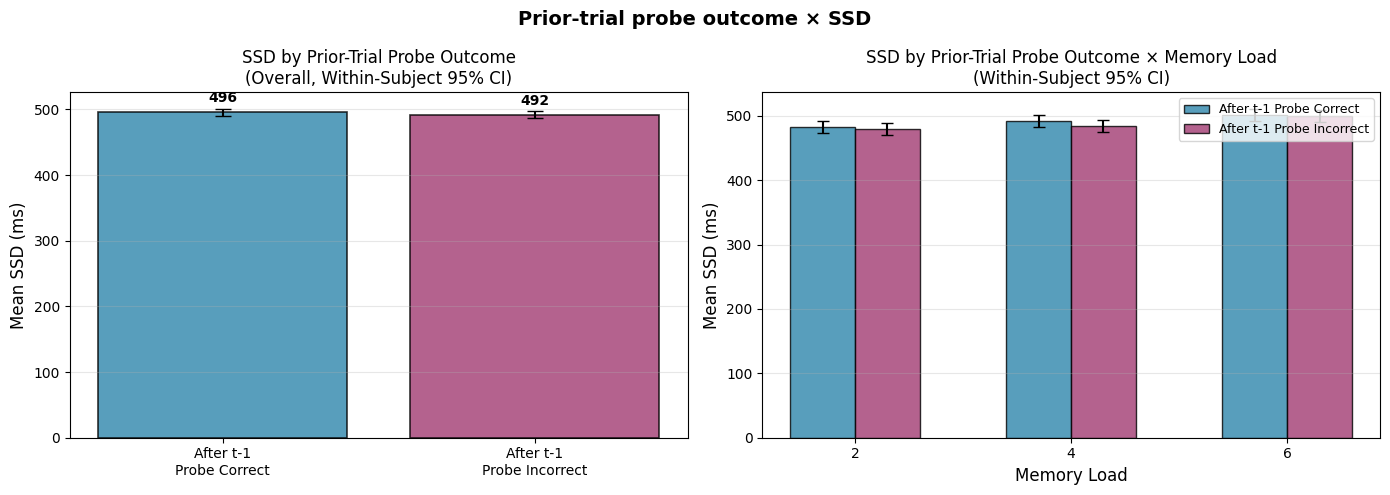


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [8]:
# === SSD BY PRIOR-TRIAL PROBE OUTCOME ===
from scipy.stats import ttest_rel

trial_data_ssd = trial_wise_data_wm.copy()
trial_data_ssd = trial_data_ssd.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_ssd['prev_probe_correct'] = (
    trial_data_ssd
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

trial_data_ssd['is_stop'] = trial_data_ssd['stop_trial_SS_trial_type'].str.lower() == 'stop'
trial_data_ssd['SSD'] = pd.to_numeric(trial_data_ssd['stop_trial_SSD'], errors='coerce')

stop_ssd = trial_data_ssd.loc[
    trial_data_ssd['is_stop'] & trial_data_ssd['prev_probe_correct'].notna() & trial_data_ssd['SSD'].notna()
].copy()

# Per-subject mean SSD by previous-trial probe outcome
subj_ssd = (
    stop_ssd
    .groupby(['participant_id', 'prev_probe_correct'])
    .agg(mean_SSD=('SSD', 'mean'), n_trials=('SSD', 'count'))
    .reset_index()
)

ssd_after_correct = subj_ssd.loc[subj_ssd['prev_probe_correct'] == 1].set_index('participant_id')
ssd_after_incorrect = subj_ssd.loc[subj_ssd['prev_probe_correct'] == 0].set_index('participant_id')
common_ssd = ssd_after_correct.index.intersection(ssd_after_incorrect.index)
sac = ssd_after_correct.loc[common_ssd]
sai = ssd_after_incorrect.loc[common_ssd]

# Overall within-subject CI
overall_matrix_ssd = pd.DataFrame({
    't-1 Correct': sac['mean_SSD'].values,
    't-1 Incorrect': sai['mean_SSD'].values,
})
ws_ci_ssd = calculate_within_subject_ci(overall_matrix_ssd)
means_ssd = [overall_matrix_ssd.iloc[:, c].mean() for c in range(2)]
cis_ssd = [ws_ci_ssd.iloc[c] if hasattr(ws_ci_ssd, 'iloc') else ws_ci_ssd[c] for c in range(2)]

# Paired t-test (overall)
n_ssd = len(common_ssd)
t_ssd, p_ssd = ttest_rel(sac['mean_SSD'], sai['mean_SSD'])
diff_ssd = sac['mean_SSD'].values - sai['mean_SSD'].values
cd_ssd = diff_ssd.mean() / diff_ssd.std() if diff_ssd.std() > 0 else np.nan
print(f"Overall: Paired t-test: t({n_ssd - 1}) = {t_ssd:.3f}, p = {p_ssd:.4f}, Cohen's d = {cd_ssd:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_ssd) * np.log(1 + t_ssd**2 / ((n_ssd) - 1)) - np.log(n_ssd)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\nBy WM Load:")
# By WM load
wm_loads_ssd = [2, 4, 6]
results_by_load_ssd = {}
for wm_load in wm_loads_ssd:
    load_data = stop_ssd.loc[stop_ssd['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(mean_SSD=('SSD', 'mean'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]
    if len(lc) > 2:
        t_l, p_l = ttest_rel(lac_c['mean_SSD'], lai_c['mean_SSD'])
        d_l = lac_c['mean_SSD'].values - lai_c['mean_SSD'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  WM Load {wm_load}: Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc)) * np.log(1 + t_l**2 / ((len(lc)) - 1)) - np.log(len(lc))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'correct': lac.loc[lc, 'mean_SSD'].values,
            'incorrect': lai.loc[lc, 'mean_SSD'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_ssd[wm_load] = {
            'after_correct': {'mean': lac.loc[lc, 'mean_SSD'].mean(), 'ci': ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]},
            'after_incorrect': {'mean': lai.loc[lc, 'mean_SSD'].mean(), 'ci': ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]},
        }
    else:
        results_by_load_ssd[wm_load] = {
            'after_correct': {'mean': lac['mean_SSD'].mean(), 'ci': 0},
            'after_incorrect': {'mean': lai['mean_SSD'].mean(), 'ci': 0},
        }

colors_lag = ['#2E86AB', '#A23B72']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe outcome × SSD', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
cond_labels = ['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect']
bars = ax1.bar(cond_labels, means_ssd, yerr=cis_ssd, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Mean SSD (ms)', fontsize=12)
ax1.set_title('SSD by Prior-Trial Probe Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_ssd, cis_ssd):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 5,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_ssd))
width = 0.3
correct_means = [results_by_load_ssd[wm]['after_correct']['mean'] for wm in wm_loads_ssd]
incorrect_means = [results_by_load_ssd[wm]['after_incorrect']['mean'] for wm in wm_loads_ssd]
correct_cis = [results_by_load_ssd[wm]['after_correct']['ci'] for wm in wm_loads_ssd]
incorrect_cis = [results_by_load_ssd[wm]['after_incorrect']['ci'] for wm in wm_loads_ssd]

ax2.bar(x - width/2, correct_means, width, yerr=correct_cis, capsize=4,
        label='After t-1 Probe Correct', color=colors_lag[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, incorrect_means, width, yerr=incorrect_cis, capsize=4,
        label='After t-1 Probe Incorrect', color=colors_lag[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Mean SSD (ms)', fontsize=12)
ax2.set_title('SSD by Prior-Trial Probe Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 7. Prior-Trial Outcome and Go Accuracy

Whether the prior trial's outcome (correct vs incorrect on the stop-signal task) predicts go accuracy on the current trial. For go trials, accuracy = correct key press; prior trial outcome = whether t-1 was correct (go: right key; stop: successful inhibition) or incorrect.

Overall: Paired t-test: t(49) = 2.710, p = 0.0093, Cohen's d = 0.387
  ΔBIC = 3.07, BF₁₀ = 4.64

By WM Load:


  WM Load 2: Paired t-test: t(49) = 2.667, p = 0.0104, Cohen's d = 0.381
  ΔBIC = 2.86, BF₁₀ = 4.19
  WM Load 4: Paired t-test: t(49) = 1.631, p = 0.1093, Cohen's d = 0.233
  ΔBIC = -1.27, BF₁₀ = 0.53
  WM Load 6: Paired t-test: t(49) = 3.245, p = 0.0021, Cohen's d = 0.464
  ΔBIC = 5.82, BF₁₀ = 18.37


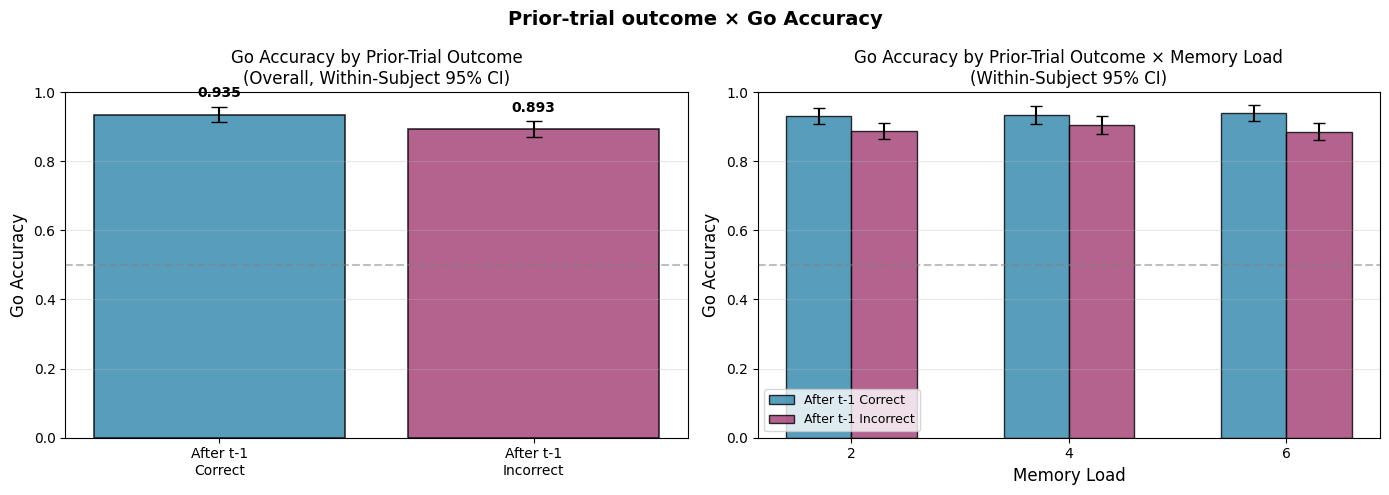


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [9]:
# === PRIOR-TRIAL OUTCOME AND GO ACCURACY ===
from scipy.stats import ttest_rel

trial_data_acc = trial_wise_data_wm.copy()
trial_data_acc = trial_data_acc.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_acc['prev_trial_correct'] = (
    trial_data_acc
    .groupby(['participant_id', 'block_num'])['stop_trial_correct_trial']
    .shift(1)
)

trial_data_acc['is_stop'] = trial_data_acc['stop_trial_SS_trial_type'].str.lower() == 'stop'
trial_data_acc['go_correct'] = pd.to_numeric(trial_data_acc['stop_trial_correct_trial'], errors='coerce')

go_with_prev = trial_data_acc.loc[
    (~trial_data_acc['is_stop']) & trial_data_acc['prev_trial_correct'].notna() & trial_data_acc['go_correct'].notna()
].copy()

# Per-subject mean go accuracy by previous-trial outcome
subj_acc = (
    go_with_prev
    .groupby(['participant_id', 'prev_trial_correct'])
    .agg(mean_go_acc=('go_correct', 'mean'), n_trials=('go_correct', 'count'))
    .reset_index()
)

acc_after_correct = subj_acc.loc[subj_acc['prev_trial_correct'] == 1].set_index('participant_id')
acc_after_incorrect = subj_acc.loc[subj_acc['prev_trial_correct'] == 0].set_index('participant_id')
common_acc = acc_after_correct.index.intersection(acc_after_incorrect.index)
aac = acc_after_correct.loc[common_acc]
aai = acc_after_incorrect.loc[common_acc]

# Overall within-subject CI
overall_matrix_acc = pd.DataFrame({
    't-1 Correct': aac['mean_go_acc'].values,
    't-1 Incorrect': aai['mean_go_acc'].values,
})
ws_ci_acc = calculate_within_subject_ci(overall_matrix_acc)
means_acc = [overall_matrix_acc.iloc[:, c].mean() for c in range(2)]
cis_acc = [ws_ci_acc.iloc[c] if hasattr(ws_ci_acc, 'iloc') else ws_ci_acc[c] for c in range(2)]

# Paired t-test (overall)
n_acc = len(common_acc)
t_acc, p_acc = ttest_rel(aac['mean_go_acc'], aai['mean_go_acc'])
diff_acc = aac['mean_go_acc'].values - aai['mean_go_acc'].values
cd_acc = diff_acc.mean() / diff_acc.std() if diff_acc.std() > 0 else np.nan
print(f"Overall: Paired t-test: t({n_acc - 1}) = {t_acc:.3f}, p = {p_acc:.4f}, Cohen's d = {cd_acc:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_acc) * np.log(1 + t_acc**2 / ((n_acc) - 1)) - np.log(n_acc)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\nBy WM Load:")

# By WM load
wm_loads_acc = [2, 4, 6]
results_by_load_acc = {}
for wm_load in wm_loads_acc:
    load_data = go_with_prev.loc[go_with_prev['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_trial_correct'])
        .agg(mean_go_acc=('go_correct', 'mean'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_trial_correct'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_trial_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'correct': lac.loc[lc, 'mean_go_acc'].values,
            'incorrect': lai.loc[lc, 'mean_go_acc'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_acc[wm_load] = {
            'after_correct': {'mean': lac.loc[lc, 'mean_go_acc'].mean(), 'ci': ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]},
            'after_incorrect': {'mean': lai.loc[lc, 'mean_go_acc'].mean(), 'ci': ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]},
        }
        t_l, p_l = ttest_rel(lac.loc[lc, 'mean_go_acc'], lai.loc[lc, 'mean_go_acc'])
        d_l = lac.loc[lc, 'mean_go_acc'].values - lai.loc[lc, 'mean_go_acc'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  WM Load {wm_load}: Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc)) * np.log(1 + t_l**2 / ((len(lc)) - 1)) - np.log(len(lc))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
    else:
        results_by_load_acc[wm_load] = {
            'after_correct': {'mean': lac['mean_go_acc'].mean(), 'ci': 0},
            'after_incorrect': {'mean': lai['mean_go_acc'].mean(), 'ci': 0},
        }

colors_lag = ['#2E86AB', '#A23B72']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial outcome × Go Accuracy', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
cond_labels = ['After t-1\nCorrect', 'After t-1\nIncorrect']
bars = ax1.bar(cond_labels, means_acc, yerr=cis_acc, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Go Accuracy', fontsize=12)
ax1.set_title('Go Accuracy by Prior-Trial Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_acc, cis_acc):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 0.02,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_acc))
width = 0.3
correct_means = [results_by_load_acc[wm]['after_correct']['mean'] for wm in wm_loads_acc]
incorrect_means = [results_by_load_acc[wm]['after_incorrect']['mean'] for wm in wm_loads_acc]
correct_cis = [results_by_load_acc[wm]['after_correct']['ci'] for wm in wm_loads_acc]
incorrect_cis = [results_by_load_acc[wm]['after_incorrect']['ci'] for wm in wm_loads_acc]

ax2.bar(x - width/2, correct_means, width, yerr=correct_cis, capsize=4,
        label='After t-1 Correct', color=colors_lag[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, incorrect_means, width, yerr=incorrect_cis, capsize=4,
        label='After t-1 Incorrect', color=colors_lag[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Go Accuracy', fontsize=12)
ax2.set_title('Go Accuracy by Prior-Trial Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 8. Does Prior Probe Outcome Predict Next Probe Outcome?

Sequential dependency analysis: does the memory probe outcome on trial t-1 (correct vs. incorrect) predict the memory probe outcome on trial t?

- **t-1 Probe Correct → Probe trial t**: probe accuracy
- **t-1 Probe Incorrect → Probe trial t**: probe accuracy

Only consecutive trials *within the same block* are considered (no cross-block lag). Trial counts are reported because the conditions are likely unbalanced (most probes are correct).

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 9–13 for omission-only analyses and Section 14 for commission-only.

DOES PRIOR PROBE OUTCOME (trial t-1) PREDICT NEXT PROBE OUTCOME (trial t)?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 50

After t-1 Probe CORRECT:
  Probe accuracy (trial t): M = 0.880, SD = 0.079
  Avg probe trials per subject: 365.2  (range: 244-414)

After t-1 Probe INCORRECT:
  Probe accuracy (trial t): M = 0.837, SD = 0.133
  Avg probe trials per subject: 54.8  (range: 6-176)

Paired t-test: t(49) = 3.090, p = 0.0033, Cohen's d = 0.441
  ΔBIC = 4.99, BF₁₀ = 12.12

--- t-1 Probe Incorrect trials per participant (Section 8: probe trials) ---
                          t-1_probe_incorrect_trials
participant_id                                      
69dc3f304137e723662d1a94                         176
6750f7eb7c60e2b2c22aeaea                         139
69e129bd8ad451d4d82ff01f                         120
5f9fdfd04296cb0102563f84                         120
69dc0bb705c5528e019815eb                         119
668e88ea6a476e76e0c1993b             

  Subjects with both conditions: 49


  After t-1 Correct:   M = 0.914, SD = 0.080, avg trials = 122.1
  After t-1 Incorrect: M = 0.866, SD = 0.138, avg trials = 18.2
  Paired t-test: t(48) = 2.945, p = 0.0050, Cohen's d = 0.425
  ΔBIC = 4.25, BF₁₀ = 8.36

--- WM Load = 4 ---

  Subjects with both conditions: 50
  After t-1 Correct:   M = 0.902, SD = 0.083, avg trials = 121.4
  After t-1 Incorrect: M = 0.864, SD = 0.151, avg trials = 18.7
  Paired t-test: t(49) = 2.338, p = 0.0235, Cohen's d = 0.334
  ΔBIC = 1.37, BF₁₀ = 1.99

--- WM Load = 6 ---

  Subjects with both conditions: 50
  After t-1 Correct:   M = 0.822, SD = 0.094, avg trials = 121.4
  After t-1 Incorrect: M = 0.777, SD = 0.172, avg trials = 18.3
  Paired t-test: t(49) = 2.344, p = 0.0232, Cohen's d = 0.335
  ΔBIC = 1.40, BF₁₀ = 2.02

VISUALIZATION


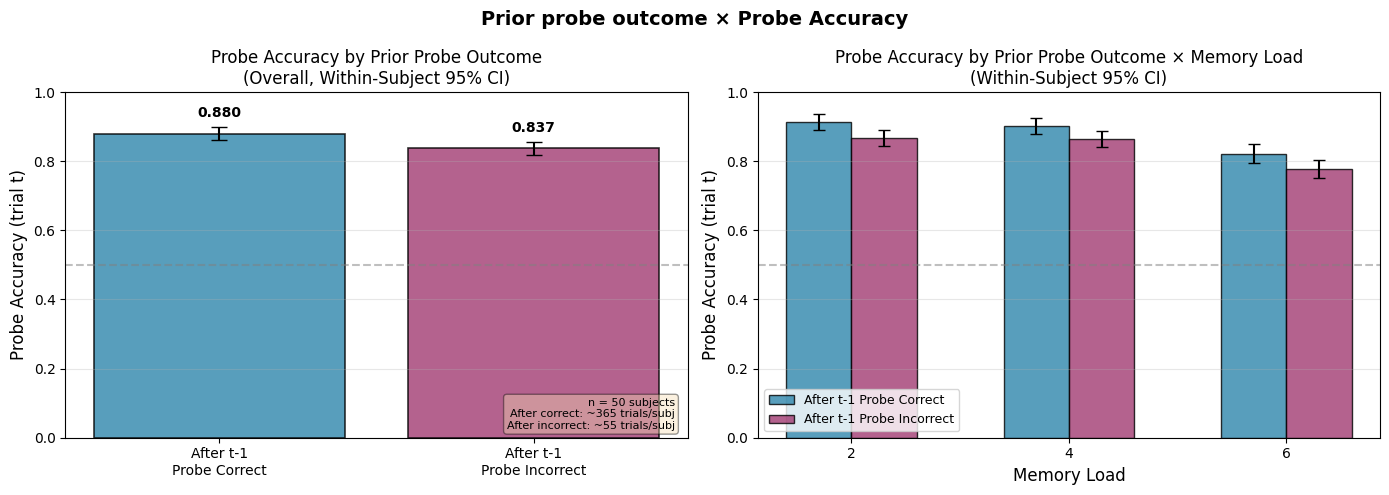


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).
Trial counts are likely unbalanced because most probes are answered correctly.


In [10]:
# === DOES PRIOR PROBE OUTCOME (trial t-1) PREDICT NEXT PROBE OUTCOME (trial t)? ===
from scipy.stats import ttest_rel

trial_data_pp = trial_wise_data_wm.copy()
trial_data_pp = trial_data_pp.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

# Lag the probe accuracy within each subject × block
trial_data_pp['prev_probe_correct'] = (
    trial_data_pp
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

# Keep only probe trials (trial t) that have a valid previous-trial probe outcome (trial t-1)
probe_with_prev = trial_data_pp.loc[
    trial_data_pp['memory_recognition_correct_trial'].notna() & trial_data_pp['prev_probe_correct'].notna()
].copy()

print("=" * 70)
print("DOES PRIOR PROBE OUTCOME (trial t-1) PREDICT NEXT PROBE OUTCOME (trial t)?")
print("=" * 70)

# --- Overall (collapsed across WM load) ---
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_pp = (
    probe_with_prev
    .groupby(['participant_id', 'prev_probe_correct'])
    .agg(
        mean_probe_acc=('memory_recognition_correct_trial', 'mean'),
        n_trials=('memory_recognition_correct_trial', 'count'),
    )
    .reset_index()
)

pac = subj_pp.loc[subj_pp['prev_probe_correct'] == 1].set_index('participant_id')
pai = subj_pp.loc[subj_pp['prev_probe_correct'] == 0].set_index('participant_id')
common_pp = pac.index.intersection(pai.index)
pac = pac.loc[common_pp]
pai = pai.loc[common_pp]

n_pp = len(common_pp)
print(f"Subjects with data in both conditions: {n_pp}")
print(f"\nAfter t-1 Probe CORRECT:")
print(f"  Probe accuracy (trial t): M = {pac['mean_probe_acc'].mean():.3f}, SD = {pac['mean_probe_acc'].std():.3f}")
print(f"  Avg probe trials per subject: {pac['n_trials'].mean():.1f}  (range: {pac['n_trials'].min()}-{pac['n_trials'].max()})")

print(f"\nAfter t-1 Probe INCORRECT:")
print(f"  Probe accuracy (trial t): M = {pai['mean_probe_acc'].mean():.3f}, SD = {pai['mean_probe_acc'].std():.3f}")
print(f"  Avg probe trials per subject: {pai['n_trials'].mean():.1f}  (range: {pai['n_trials'].min()}-{pai['n_trials'].max()})")

# Paired t-test
t_pp, p_pp = ttest_rel(pac['mean_probe_acc'], pai['mean_probe_acc'])
diff_pp = pac['mean_probe_acc'].values - pai['mean_probe_acc'].values
cd_pp = diff_pp.mean() / diff_pp.std() if diff_pp.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_pp - 1}) = {t_pp:.3f}, p = {p_pp:.4f}, Cohen's d = {cd_pp:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_pp) * np.log(1 + t_pp**2 / ((n_pp) - 1)) - np.log(n_pp)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
# Per-participant t-1 probe incorrect trial counts (Section 8: probe trials)
print("\n--- t-1 Probe Incorrect trials per participant (Section 8: probe trials) ---")
pai_n = pai[['n_trials']].copy()
pai_n.columns = ['t-1_probe_incorrect_trials']
print(pai_n.sort_values('t-1_probe_incorrect_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_pp = [2, 4, 6]
results_by_load_pp = {}

for wm_load in wm_loads_pp:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = probe_with_prev.loc[probe_with_prev['memory_trial_stimLength'] == wm_load]

    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(mean_probe_acc=('memory_recognition_correct_trial', 'mean'), n_trials=('memory_recognition_correct_trial', 'count'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]

    results_by_load_pp[wm_load] = {
        'after_correct':   {'mean': lac_c['mean_probe_acc'].mean(), 'ci': 0},
        'after_incorrect': {'mean': lai_c['mean_probe_acc'].mean(), 'ci': 0},
    }

    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'correct': lac_c['mean_probe_acc'].values,
            'incorrect': lai_c['mean_probe_acc'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_pp[wm_load]['after_correct']['ci'] = ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]
        results_by_load_pp[wm_load]['after_incorrect']['ci'] = ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]
        t_l, p_l = ttest_rel(lac_c['mean_probe_acc'], lai_c['mean_probe_acc'])
        d_l = lac_c['mean_probe_acc'].values - lai_c['mean_probe_acc'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc)}")
        print(f"  After t-1 Correct:   M = {lac_c['mean_probe_acc'].mean():.3f}, SD = {lac_c['mean_probe_acc'].std():.3f}, avg trials = {lac_c['n_trials'].mean():.1f}")
        print(f"  After t-1 Incorrect: M = {lai_c['mean_probe_acc'].mean():.3f}, SD = {lai_c['mean_probe_acc'].std():.3f}, avg trials = {lai_c['n_trials'].mean():.1f}")
        print(f"  Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc)) * np.log(1 + t_l**2 / ((len(lc)) - 1)) - np.log(len(lc))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
    else:
        print(f"  Not enough subjects for paired t-test")

# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_lag = ['#2E86AB', '#A23B72']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior probe outcome × Probe Accuracy', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
overall_matrix_pp = pd.DataFrame({
    't-1 Correct':   pac['mean_probe_acc'].values,
    't-1 Incorrect': pai['mean_probe_acc'].values,
})
ws_ci_pp = calculate_within_subject_ci(overall_matrix_pp)
means_pp = [overall_matrix_pp.iloc[:, c].mean() for c in range(2)]
cis_pp = [ws_ci_pp.iloc[c] if hasattr(ws_ci_pp, 'iloc') else ws_ci_pp[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect']
bars = ax1.bar(cond_labels, means_pp, yerr=cis_pp, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Probe Accuracy (trial t)', fontsize=12)
ax1.set_title('Probe Accuracy by Prior Probe Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')

for bar, mean, ci in zip(bars, means_pp, cis_pp):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 0.02,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.text(0.98, 0.02,
         f'n = {n_pp} subjects\n'
         f'After correct: ~{pac["n_trials"].mean():.0f} trials/subj\n'
         f'After incorrect: ~{pai["n_trials"].mean():.0f} trials/subj',
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_pp))
width = 0.3
correct_means = [results_by_load_pp[wm]['after_correct']['mean'] for wm in wm_loads_pp]
incorrect_means = [results_by_load_pp[wm]['after_incorrect']['mean'] for wm in wm_loads_pp]
correct_cis = [results_by_load_pp[wm]['after_correct']['ci'] for wm in wm_loads_pp]
incorrect_cis = [results_by_load_pp[wm]['after_incorrect']['ci'] for wm in wm_loads_pp]

ax2.bar(x - width/2, correct_means, width, yerr=correct_cis, capsize=4,
        label='After t-1 Probe Correct', color=colors_lag[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, incorrect_means, width, yerr=incorrect_cis, capsize=4,
        label='After t-1 Probe Incorrect', color=colors_lag[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Probe Accuracy (trial t)', fontsize=12)
ax2.set_title('Probe Accuracy by Prior Probe Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")
print("Trial counts are likely unbalanced because most probes are answered correctly.")

## 9. Does a Probe Omission on Trial t-1 Predict Stop Signal Success?

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict whether the participant successfully inhibits on a stop trial at trial t?

- **t-1 Probe Omission → Stop trial t**: stop success rate
- **t-1 Probe Response → Stop trial t**: stop success rate

Only consecutive trials *within the same block* are considered (no cross-block lag). Trial counts are reported because the conditions are likely unbalanced (most probes are answered).

DOES PROBE OMISSION ON TRIAL t-1 PREDICT STOP SUCCESS?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 32

After t-1 Probe OMISSION:
  Stop success rate: M = 0.534, SD = 0.368
  Avg stop trials per subject: 5.2  (range: 1-23)

After t-1 Probe RESPONSE:
  Stop success rate: M = 0.534, SD = 0.036
  Avg stop trials per subject: 135.1  (range: 117-141)

Paired t-test: t(31) = -0.000, p = 1.0000, Cohen's d = -0.000
  ΔBIC = -3.47, BF₁₀ = 0.18

--- t-1 Probe Omission trials per participant (Section 9: stop trials) ---
                          t-1_probe_omission_trials
participant_id                                     
69dc3f304137e723662d1a94                         23
668e88ea6a476e76e0c1993b                         18
6100372e3a116cb5cb36ebea                         15
5f9fdfd04296cb0102563f84                         12
6750f7eb7c60e2b2c22aeaea                         11
69e129bd8ad451d4d82ff01f                         10
6143af8721d1445864c4f6c8      

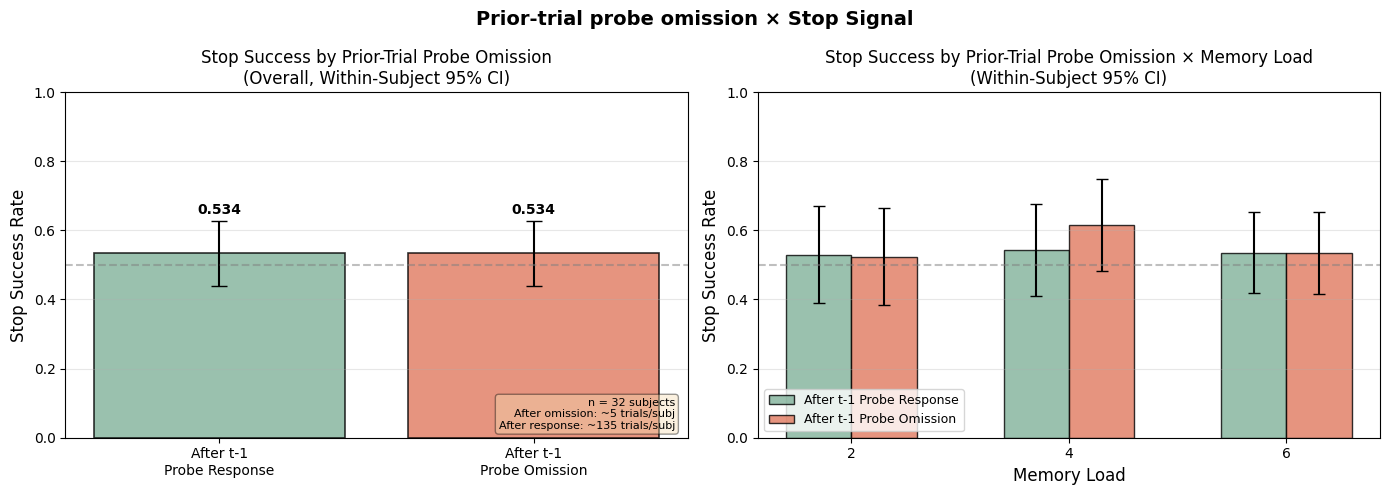


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).
Trial counts are likely unbalanced because most probes are answered.


In [11]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT STOP SUCCESS? ===
from scipy.stats import ttest_rel

trial_data_om = trial_wise_data_wm.copy()
trial_data_om = trial_data_om.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

# Probe omission = no response (memory_recognition_rt is NaN)
trial_data_om['probe_omission'] = trial_data_om['memory_recognition_rt'].isna().astype(int)
trial_data_om['prev_probe_omission'] = (
    trial_data_om
    .groupby(['participant_id', 'block_num'])['probe_omission']
    .shift(1)
)

trial_data_om['is_stop'] = (trial_data_om['stop_trial_SS_trial_type'] == 'stop')
trial_data_om['stop_success'] = (
    trial_data_om['is_stop'] & (trial_data_om['stop_trial_correct_trial'] == 1)
).astype(float)

stop_with_om = trial_data_om.loc[
    trial_data_om['is_stop'] & trial_data_om['prev_probe_omission'].notna()
].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT STOP SUCCESS?")
print("=" * 70)

# --- Overall ---
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_om = (
    stop_with_om
    .groupby(['participant_id', 'prev_probe_omission'])
    .agg(
        stop_success_rate=('stop_success', 'mean'),
        n_trials=('stop_success', 'count'),
    )
    .reset_index()
)

after_omission = subj_om.loc[subj_om['prev_probe_omission'] == 1].set_index('participant_id')
after_response = subj_om.loc[subj_om['prev_probe_omission'] == 0].set_index('participant_id')
common_om = after_omission.index.intersection(after_response.index)
ao = after_omission.loc[common_om]
ar = after_response.loc[common_om]

n_om = len(common_om)
print(f"Subjects with data in both conditions: {n_om}")
print(f"\nAfter t-1 Probe OMISSION:")
print(f"  Stop success rate: M = {ao['stop_success_rate'].mean():.3f}, SD = {ao['stop_success_rate'].std():.3f}")
print(f"  Avg stop trials per subject: {ao['n_trials'].mean():.1f}  (range: {ao['n_trials'].min()}-{ao['n_trials'].max()})")

print(f"\nAfter t-1 Probe RESPONSE:")
print(f"  Stop success rate: M = {ar['stop_success_rate'].mean():.3f}, SD = {ar['stop_success_rate'].std():.3f}")
print(f"  Avg stop trials per subject: {ar['n_trials'].mean():.1f}  (range: {ar['n_trials'].min()}-{ar['n_trials'].max()})")

t_om, p_om = ttest_rel(ao['stop_success_rate'], ar['stop_success_rate'])
diff_om = ao['stop_success_rate'].values - ar['stop_success_rate'].values
cd_om = diff_om.mean() / diff_om.std() if diff_om.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_om - 1}) = {t_om:.3f}, p = {p_om:.4f}, Cohen's d = {cd_om:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_om) * np.log(1 + t_om**2 / ((n_om) - 1)) - np.log(n_om)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
# Per-participant t-1 probe omission trial counts
print("\n--- t-1 Probe Omission trials per participant (Section 9: stop trials) ---")
ao_n = ao[['n_trials']].copy()
ao_n.columns = ['t-1_probe_omission_trials']
print(ao_n.sort_values('t-1_probe_omission_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_om = [2, 4, 6]
results_by_load_om = {}

for wm_load in wm_loads_om:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = stop_with_om.loc[stop_with_om['memory_trial_stimLength'] == wm_load]

    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_omission'])
        .agg(stop_success_rate=('stop_success', 'mean'), n_trials=('stop_success', 'count'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_probe_omission'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_probe_omission'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]

    results_by_load_om[wm_load] = {
        'after_omission': {'mean': lac_c['stop_success_rate'].mean(), 'ci': 0},
        'after_response': {'mean': lai_c['stop_success_rate'].mean(), 'ci': 0},
    }

    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'omission': lac_c['stop_success_rate'].values,
            'response': lai_c['stop_success_rate'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_om[wm_load]['after_omission']['ci'] = ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]
        results_by_load_om[wm_load]['after_response']['ci'] = ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]
        t_l, p_l = ttest_rel(lac_c['stop_success_rate'], lai_c['stop_success_rate'])
        d_l = lac_c['stop_success_rate'].values - lai_c['stop_success_rate'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc)}")
        print(f"  After t-1 Omission: M = {lac_c['stop_success_rate'].mean():.3f}, SD = {lac_c['stop_success_rate'].std():.3f}, avg trials = {lac_c['n_trials'].mean():.1f}")
        print(f"  After t-1 Response: M = {lai_c['stop_success_rate'].mean():.3f}, SD = {lai_c['stop_success_rate'].std():.3f}, avg trials = {lai_c['n_trials'].mean():.1f}")
        print(f"  Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc)) * np.log(1 + t_l**2 / ((len(lc)) - 1)) - np.log(len(lc))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
    else:
        print(f"  Not enough subjects for paired t-test")

# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_om = ['#81B29A', '#E07A5F']  # response (left) vs omission (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe omission × Stop Signal', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
overall_matrix_om = pd.DataFrame({
    't-1 Response': ar['stop_success_rate'].values,
    't-1 Omission': ao['stop_success_rate'].values,
})
ws_ci_om = calculate_within_subject_ci(overall_matrix_om)
means_om = [overall_matrix_om.iloc[:, c].mean() for c in range(2)]
cis_om = [ws_ci_om.iloc[c] if hasattr(ws_ci_om, 'iloc') else ws_ci_om[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Response', 'After t-1\nProbe Omission']
bars = ax1.bar(cond_labels, means_om, yerr=cis_om, capsize=6, color=colors_om, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Stop Success Rate', fontsize=12)
ax1.set_title('Stop Success by Prior-Trial Probe Omission\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')

for bar, mean, ci in zip(bars, means_om, cis_om):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.text(0.98, 0.02,
         f'n = {n_om} subjects\n'
         f'After omission: ~{ao["n_trials"].mean():.0f} trials/subj\n'
         f'After response: ~{ar["n_trials"].mean():.0f} trials/subj',
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_om))
width = 0.3
omission_means = [results_by_load_om[wm]['after_omission']['mean'] for wm in wm_loads_om]
response_means = [results_by_load_om[wm]['after_response']['mean'] for wm in wm_loads_om]
omission_cis = [results_by_load_om[wm]['after_omission']['ci'] for wm in wm_loads_om]
response_cis = [results_by_load_om[wm]['after_response']['ci'] for wm in wm_loads_om]

ax2.bar(x - width/2, response_means, width, yerr=response_cis, capsize=4,
        label='After t-1 Probe Response', color=colors_om[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, omission_means, width, yerr=omission_cis, capsize=4,
        label='After t-1 Probe Omission', color=colors_om[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Stop Success Rate', fontsize=12)
ax2.set_title('Stop Success by Prior-Trial Probe Omission × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")
print("Trial counts are likely unbalanced because most probes are answered.")

## 10. Does a Probe Omission on Trial t-1 Predict Go Omission?

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict whether the participant omits (fails to respond) on a go trial at trial t?

- **t-1 Probe Omission → Go trial t**: go omission rate
- **t-1 Probe Response → Go trial t**: go omission rate

Only consecutive trials *within the same block* are considered (no cross-block lag). Go omission = no response on the go trial (`stop_trial_rt` is NaN).

DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO OMISSION?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 37

After t-1 Probe OMISSION:
  Go omission rate: M = 0.117, SD = 0.270
  Avg go trials per subject: 8.0  (range: 1-50)

After t-1 Probe RESPONSE:
  Go omission rate: M = 0.036, SD = 0.053
  Avg go trials per subject: 271.8  (range: 230-284)

Paired t-test: t(36) = 1.915, p = 0.0635, Cohen's d = 0.319
  ΔBIC = -0.02, BF₁₀ = 0.99

--- t-1 Probe Omission trials per participant (Section 10: go trials) ---
                          t-1_probe_omission_trials
participant_id                                     
69dc3f304137e723662d1a94                         50
668e88ea6a476e76e0c1993b                         35
6750f7eb7c60e2b2c22aeaea                         26
6100372e3a116cb5cb36ebea                         22
69e129bd8ad451d4d82ff01f                         18
5f9fdfd04296cb0102563f84                         15
6143af8721d1445864c4f6c8                

/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_31375/2807752939.py:106: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_by_load_goom[wm_load]['after_omission']['ci'] = ws_ci_wm[0]
/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_31375/2807752939.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_by_load_goom[wm_load]['after_response']['ci'] = ws_ci_wm[1]
/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_31375/2807752939.py:106: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (

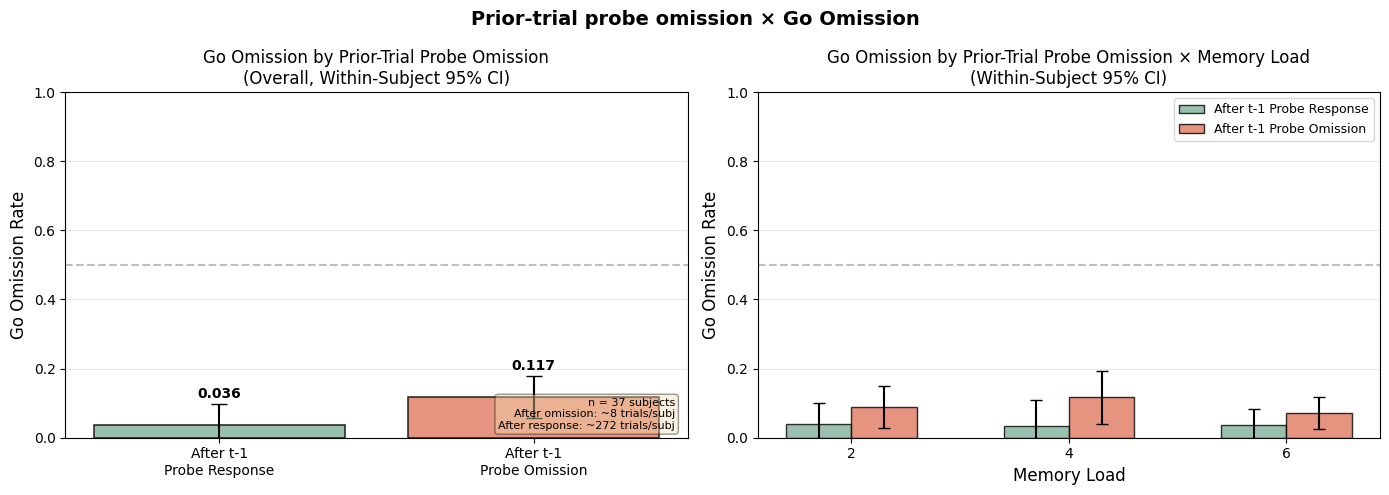


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).
Trial counts are likely unbalanced because most probes are answered.


In [12]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO OMISSION? ===
from scipy.stats import ttest_rel

trial_data_goom = trial_wise_data_wm.copy()
trial_data_goom = trial_data_goom.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

# Probe omission = no response (memory_recognition_rt is NaN)
trial_data_goom['probe_omission'] = trial_data_goom['memory_recognition_rt'].isna().astype(int)
trial_data_goom['prev_probe_omission'] = (
    trial_data_goom
    .groupby(['participant_id', 'block_num'])['probe_omission']
    .shift(1)
)

trial_data_goom['is_go'] = (trial_data_goom['stop_trial_SS_trial_type'] == 'go')
trial_data_goom['go_omission'] = (
    trial_data_goom['is_go'] & trial_data_goom['stop_trial_rt'].isna()
).astype(float)

go_with_om = trial_data_goom.loc[
    trial_data_goom['is_go'] & trial_data_goom['prev_probe_omission'].notna()
].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO OMISSION?")
print("=" * 70)

# --- Overall ---
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_goom = (
    go_with_om
    .groupby(['participant_id', 'prev_probe_omission'])
    .agg(
        go_omission_rate=('go_omission', 'mean'),
        n_trials=('go_omission', 'count'),
    )
    .reset_index()
)

after_om_go = subj_goom.loc[subj_goom['prev_probe_omission'] == 1].set_index('participant_id')
after_resp_go = subj_goom.loc[subj_goom['prev_probe_omission'] == 0].set_index('participant_id')
common_goom = after_om_go.index.intersection(after_resp_go.index)
aog = after_om_go.loc[common_goom]
arg = after_resp_go.loc[common_goom]

n_goom = len(common_goom)
print(f"Subjects with data in both conditions: {n_goom}")
print(f"\nAfter t-1 Probe OMISSION:")
print(f"  Go omission rate: M = {aog['go_omission_rate'].mean():.3f}, SD = {aog['go_omission_rate'].std():.3f}")
print(f"  Avg go trials per subject: {aog['n_trials'].mean():.1f}  (range: {aog['n_trials'].min()}-{aog['n_trials'].max()})")

print(f"\nAfter t-1 Probe RESPONSE:")
print(f"  Go omission rate: M = {arg['go_omission_rate'].mean():.3f}, SD = {arg['go_omission_rate'].std():.3f}")
print(f"  Avg go trials per subject: {arg['n_trials'].mean():.1f}  (range: {arg['n_trials'].min()}-{arg['n_trials'].max()})")

t_goom, p_goom = ttest_rel(aog['go_omission_rate'], arg['go_omission_rate'])
diff_goom = aog['go_omission_rate'].values - arg['go_omission_rate'].values
cd_goom = diff_goom.mean() / diff_goom.std() if diff_goom.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_goom - 1}) = {t_goom:.3f}, p = {p_goom:.4f}, Cohen's d = {cd_goom:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_goom) * np.log(1 + t_goom**2 / ((n_goom) - 1)) - np.log(n_goom)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
# Per-participant t-1 probe omission trial counts
print("\n--- t-1 Probe Omission trials per participant (Section 10: go trials) ---")
aog_n = aog[['n_trials']].copy()
aog_n.columns = ['t-1_probe_omission_trials']
print(aog_n.sort_values('t-1_probe_omission_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_goom = [2, 4, 6]
results_by_load_goom = {}

for wm_load in wm_loads_goom:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = go_with_om.loc[go_with_om['memory_trial_stimLength'] == wm_load]

    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_omission'])
        .agg(go_omission_rate=('go_omission', 'mean'), n_trials=('go_omission', 'count'))
        .reset_index()
    )
    loc = load_subj.loc[load_subj['prev_probe_omission'] == 1].set_index('participant_id')
    lorc = load_subj.loc[load_subj['prev_probe_omission'] == 0].set_index('participant_id')
    lc_goom = loc.index.intersection(lorc.index)
    loc_c = loc.loc[lc_goom]
    lorc_c = lorc.loc[lc_goom]

    results_by_load_goom[wm_load] = {
        'after_omission': {'mean': loc_c['go_omission_rate'].mean(), 'ci': 0},
        'after_response': {'mean': lorc_c['go_omission_rate'].mean(), 'ci': 0},
    }

    if len(lc_goom) > 2:
        wm_matrix = pd.DataFrame({
            'omission': loc_c['go_omission_rate'].values,
            'response': lorc_c['go_omission_rate'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_goom[wm_load]['after_omission']['ci'] = ws_ci_wm[0]
        results_by_load_goom[wm_load]['after_response']['ci'] = ws_ci_wm[1]
        t_l, p_l = ttest_rel(loc_c['go_omission_rate'], lorc_c['go_omission_rate'])
        d_l = loc_c['go_omission_rate'].values - lorc_c['go_omission_rate'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc_goom)}")
        print(f"  After t-1 Omission: M = {loc_c['go_omission_rate'].mean():.3f}, SD = {loc_c['go_omission_rate'].std():.3f}, avg trials = {loc_c['n_trials'].mean():.1f}")
        print(f"  After t-1 Response: M = {lorc_c['go_omission_rate'].mean():.3f}, SD = {lorc_c['go_omission_rate'].std():.3f}, avg trials = {lorc_c['n_trials'].mean():.1f}")
        print(f"  Paired t-test: t({len(lc_goom)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc_goom)) * np.log(1 + t_l**2 / ((len(lc_goom)) - 1)) - np.log(len(lc_goom))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
    else:
        print(f"  Not enough subjects for paired t-test")

# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_goom = ['#81B29A', '#E07A5F']  # response (left) vs omission (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe omission × Go Omission', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
overall_matrix_goom = pd.DataFrame({
    't-1 Response': arg['go_omission_rate'].values,
    't-1 Omission': aog['go_omission_rate'].values,
})
ws_ci_goom = calculate_within_subject_ci(overall_matrix_goom)
means_goom = [overall_matrix_goom.iloc[:, c].mean() for c in range(2)]
cis_goom = [ws_ci_goom[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Response', 'After t-1\nProbe Omission']
bars = ax1.bar(cond_labels, means_goom, yerr=cis_goom, capsize=6, color=colors_goom, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Go Omission Rate', fontsize=12)
ax1.set_title('Go Omission by Prior-Trial Probe Omission\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')

for bar, mean, ci in zip(bars, means_goom, cis_goom):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.text(0.98, 0.02,
         f'n = {n_goom} subjects\n'
         f'After omission: ~{aog["n_trials"].mean():.0f} trials/subj\n'
         f'After response: ~{arg["n_trials"].mean():.0f} trials/subj',
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_goom))
width = 0.3
omission_means = [results_by_load_goom[wm]['after_omission']['mean'] for wm in wm_loads_goom]
response_means = [results_by_load_goom[wm]['after_response']['mean'] for wm in wm_loads_goom]
omission_cis = [results_by_load_goom[wm]['after_omission']['ci'] for wm in wm_loads_goom]
response_cis = [results_by_load_goom[wm]['after_response']['ci'] for wm in wm_loads_goom]

ax2.bar(x - width/2, response_means, width, yerr=response_cis, capsize=4,
        label='After t-1 Probe Response', color=colors_goom[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, omission_means, width, yerr=omission_cis, capsize=4,
        label='After t-1 Probe Omission', color=colors_goom[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Go Omission Rate', fontsize=12)
ax2.set_title('Go Omission by Prior-Trial Probe Omission × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")
print("Trial counts are likely unbalanced because most probes are answered.")

## 11. Does a Probe Omission on Trial t-1 Predict Go RT?

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict **mean go trial RT** on trial t?

- **t-1 Probe Omission → Go trial t**: mean RT (ms)
- **t-1 Probe Response → Go trial t**: mean RT (ms)

Only consecutive trials *within the same block* are considered. Go trials with valid RT (non-omission) only.

DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO RT?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 35

After t-1 Probe OMISSION: M = 802 ms, SD = 124
After t-1 Probe RESPONSE: M = 799 ms, SD = 103

Paired t-test: t(34) = 0.233, p = 0.8172, Cohen's d = 0.040
  ΔBIC = -3.50, BF₁₀ = 0.17

--- t-1 Probe Omission trials per participant (Section 11: go RT trials) ---
                          t-1_probe_omission_trials
participant_id                                     
668e88ea6a476e76e0c1993b                         35
6750f7eb7c60e2b2c22aeaea                         26
69dc3f304137e723662d1a94                         24
6100372e3a116cb5cb36ebea                         19
69e129bd8ad451d4d82ff01f                         16
5f9fdfd04296cb0102563f84                         14
6143af8721d1445864c4f6c8                         12
6710123050faa590f80d96e5                         11
69ebb724d406145f4e51c8ec                          9
69782502ea3a21b5c59141aa       

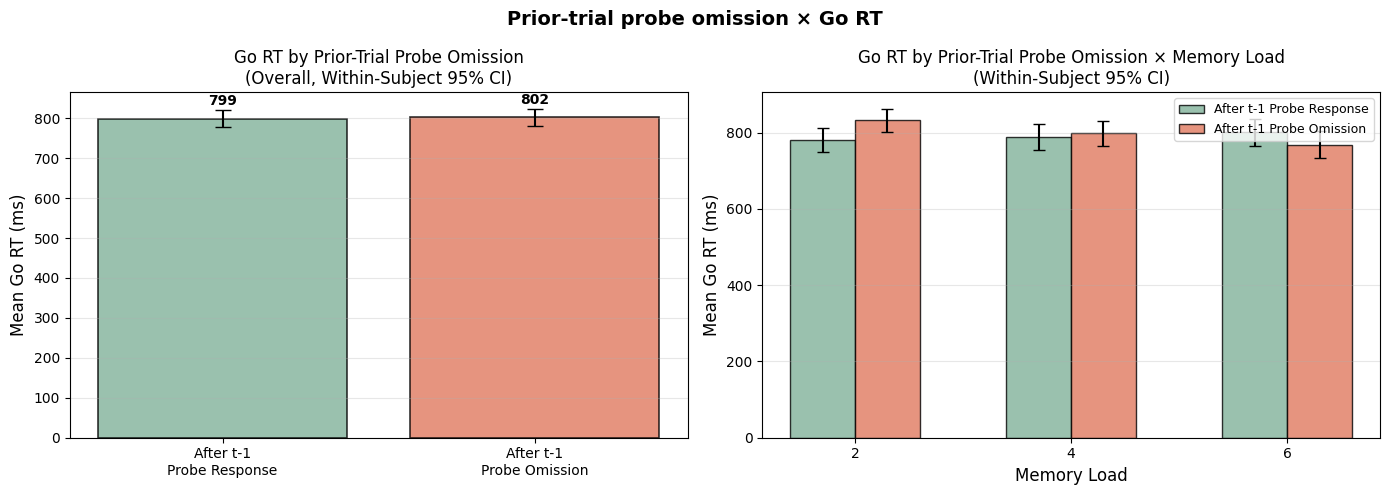


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [13]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO RT? ===
from scipy.stats import ttest_rel

trial_data_rt = trial_wise_data_wm.copy()
trial_data_rt = trial_data_rt.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_rt['probe_omission'] = trial_data_rt['memory_recognition_rt'].isna().astype(int)
trial_data_rt['prev_probe_omission'] = (
    trial_data_rt.groupby(['participant_id', 'block_num'])['probe_omission'].shift(1)
)

trial_data_rt['is_go'] = (trial_data_rt['stop_trial_SS_trial_type'] == 'go')
trial_data_rt['go_rt'] = pd.to_numeric(trial_data_rt['stop_trial_rt'], errors='coerce')

# Only go trials with valid RT (exclude go omissions)
go_rt_data = trial_data_rt.loc[
    trial_data_rt['is_go'] & trial_data_rt['go_rt'].notna() & trial_data_rt['prev_probe_omission'].notna()
].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO RT?")
print("=" * 70)
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_rt = (
    go_rt_data
    .groupby(['participant_id', 'prev_probe_omission'])
    .agg(mean_go_rt=('go_rt', 'mean'), n_trials=('go_rt', 'count'))
    .reset_index()
)

rt_after_om = subj_rt.loc[subj_rt['prev_probe_omission'] == 1].set_index('participant_id')
rt_after_resp = subj_rt.loc[subj_rt['prev_probe_omission'] == 0].set_index('participant_id')
common_rt = rt_after_om.index.intersection(rt_after_resp.index)
rao = rt_after_om.loc[common_rt]
rar = rt_after_resp.loc[common_rt]

n_rt = len(common_rt)
print(f"Subjects with data in both conditions: {n_rt}")
print(f"\nAfter t-1 Probe OMISSION: M = {rao['mean_go_rt'].mean():.0f} ms, SD = {rao['mean_go_rt'].std():.0f}")
print(f"After t-1 Probe RESPONSE: M = {rar['mean_go_rt'].mean():.0f} ms, SD = {rar['mean_go_rt'].std():.0f}")

t_rt, p_rt = ttest_rel(rao['mean_go_rt'], rar['mean_go_rt'])
diff_rt = rao['mean_go_rt'].values - rar['mean_go_rt'].values
cd_rt = diff_rt.mean() / diff_rt.std() if diff_rt.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_rt - 1}) = {t_rt:.3f}, p = {p_rt:.4f}, Cohen's d = {cd_rt:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_rt) * np.log(1 + t_rt**2 / ((n_rt) - 1)) - np.log(n_rt)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
# Per-participant t-1 probe omission trial counts
print("\n--- t-1 Probe Omission trials per participant (Section 11: go RT trials) ---")
rao_n = rao[['n_trials']].copy()
rao_n.columns = ['t-1_probe_omission_trials']
print(rao_n.sort_values('t-1_probe_omission_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_rt = [2, 4, 6]
results_by_load_rt = {}

for wm_load in wm_loads_rt:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = go_rt_data.loc[go_rt_data['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data.groupby(['participant_id', 'prev_probe_omission'])
        .agg(mean_go_rt=('go_rt', 'mean'), n_trials=('go_rt', 'count'))
        .reset_index()
    )
    loc = load_subj.loc[load_subj['prev_probe_omission'] == 1].set_index('participant_id')
    lorc = load_subj.loc[load_subj['prev_probe_omission'] == 0].set_index('participant_id')
    lc_rt = loc.index.intersection(lorc.index)
    loc_c = loc.loc[lc_rt]
    lorc_c = lorc.loc[lc_rt]

    results_by_load_rt[wm_load] = {
        'after_omission': {'mean': loc_c['mean_go_rt'].mean(), 'ci': 0},
        'after_response': {'mean': lorc_c['mean_go_rt'].mean(), 'ci': 0},
    }

    if len(lc_rt) > 2:
        wm_matrix = pd.DataFrame({
            'omission': loc_c['mean_go_rt'].values,
            'response': lorc_c['mean_go_rt'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_rt[wm_load]['after_omission']['ci'] = np.asarray(ws_ci_wm)[0]
        results_by_load_rt[wm_load]['after_response']['ci'] = np.asarray(ws_ci_wm)[1]
        t_l, p_l = ttest_rel(loc_c['mean_go_rt'], lorc_c['mean_go_rt'])
        d_l = loc_c['mean_go_rt'].values - lorc_c['mean_go_rt'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc_rt)}")
        print(f"  After t-1 Omission: M = {loc_c['mean_go_rt'].mean():.0f} ms")
        print(f"  After t-1 Response: M = {lorc_c['mean_go_rt'].mean():.0f} ms")
        print(f"  Paired t-test: t({len(lc_rt)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc_rt)) * np.log(1 + t_l**2 / ((len(lc_rt)) - 1)) - np.log(len(lc_rt))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_rt = ['#81B29A', '#E07A5F']  # response (left) vs omission (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe omission × Go RT', fontsize=14, fontweight='bold')

overall_matrix_rt = pd.DataFrame({
    't-1 Response': rar['mean_go_rt'].values,
    't-1 Omission': rao['mean_go_rt'].values,
})
ws_ci_rt = calculate_within_subject_ci(overall_matrix_rt)
means_rt = [overall_matrix_rt.iloc[:, c].mean() for c in range(2)]
cis_rt = [np.asarray(ws_ci_rt)[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Response', 'After t-1\nProbe Omission']
ax1 = axes[0]
bars = ax1.bar(cond_labels, means_rt, yerr=cis_rt, capsize=6, color=colors_rt, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Mean Go RT (ms)', fontsize=12)
ax1.set_title('Go RT by Prior-Trial Probe Omission\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_rt, cis_rt):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 5,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[1]
x = np.arange(len(wm_loads_rt))
width = 0.3
omission_means = [results_by_load_rt[wm]['after_omission']['mean'] for wm in wm_loads_rt]
response_means = [results_by_load_rt[wm]['after_response']['mean'] for wm in wm_loads_rt]
omission_cis = [results_by_load_rt[wm]['after_omission']['ci'] for wm in wm_loads_rt]
response_cis = [results_by_load_rt[wm]['after_response']['ci'] for wm in wm_loads_rt]

ax2.bar(x - width/2, response_means, width, yerr=response_cis, capsize=4,
        label='After t-1 Probe Response', color=colors_rt[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, omission_means, width, yerr=omission_cis, capsize=4,
        label='After t-1 Probe Omission', color=colors_rt[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Mean Go RT (ms)', fontsize=12)
ax2.set_title('Go RT by Prior-Trial Probe Omission × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 12. Does a Probe Omission on Trial t-1 Predict SSD?

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict **mean SSD** (stop-signal delay) on a stop trial at trial t?

- **t-1 Probe Omission → Stop trial t**: mean SSD (ms)
- **t-1 Probe Response → Stop trial t**: mean SSD (ms)

Only consecutive trials *within the same block* are considered.

DOES PROBE OMISSION ON TRIAL t-1 PREDICT SSD?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 32

After t-1 Probe OMISSION: M = 512 ms, SD = 127
After t-1 Probe RESPONSE: M = 497 ms, SD = 129

Paired t-test: t(31) = 1.081, p = 0.2879, Cohen's d = 0.194
  ΔBIC = -2.28, BF₁₀ = 0.32

--- t-1 Probe Omission trials per participant (Section 12: stop trials) ---
                          t-1_probe_omission_trials
participant_id                                     
69dc3f304137e723662d1a94                         23
668e88ea6a476e76e0c1993b                         18
6100372e3a116cb5cb36ebea                         15
5f9fdfd04296cb0102563f84                         12
6750f7eb7c60e2b2c22aeaea                         11
69e129bd8ad451d4d82ff01f                         10
6143af8721d1445864c4f6c8                          9
5efd32d5ebff0517d77b8e4c                          7
6710123050faa590f80d96e5                          7
699ec098d5e833b119bb99dc          

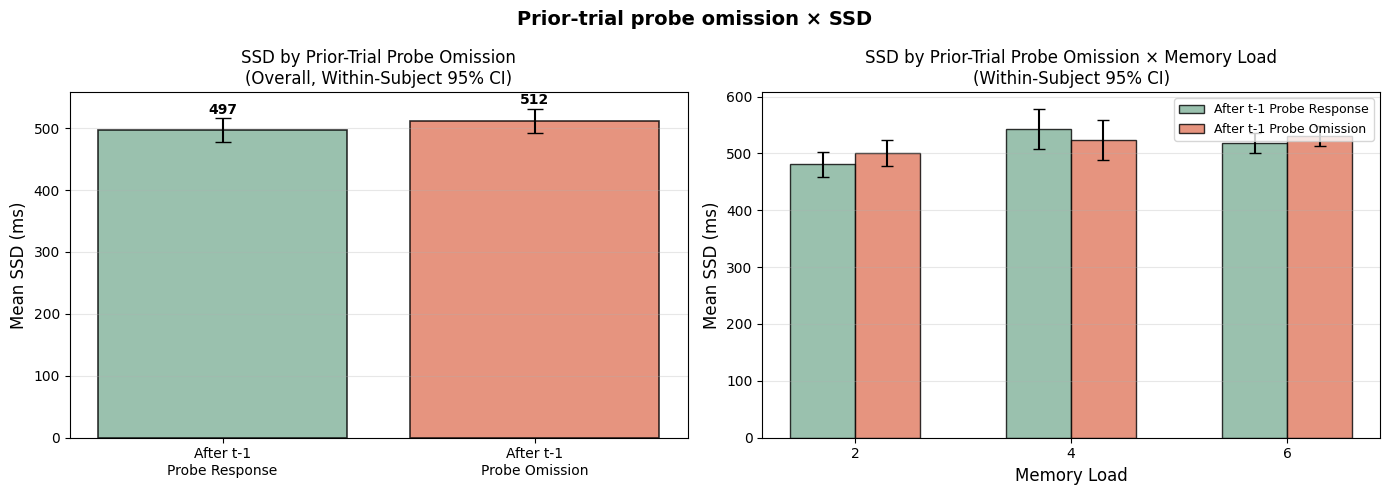


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [14]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT SSD? ===
from scipy.stats import ttest_rel

trial_data_ssd = trial_wise_data_wm.copy()
trial_data_ssd = trial_data_ssd.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_ssd['probe_omission'] = trial_data_ssd['memory_recognition_rt'].isna().astype(int)
trial_data_ssd['prev_probe_omission'] = (
    trial_data_ssd.groupby(['participant_id', 'block_num'])['probe_omission'].shift(1)
)

trial_data_ssd['is_stop'] = (trial_data_ssd['stop_trial_SS_trial_type'] == 'stop')
trial_data_ssd['SSD'] = pd.to_numeric(trial_data_ssd['stop_trial_SSD'], errors='coerce')

stop_ssd_data = trial_data_ssd.loc[
    trial_data_ssd['is_stop'] & trial_data_ssd['SSD'].notna() & trial_data_ssd['prev_probe_omission'].notna()
].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT SSD?")
print("=" * 70)
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_ssd = (
    stop_ssd_data
    .groupby(['participant_id', 'prev_probe_omission'])
    .agg(mean_SSD=('SSD', 'mean'), n_trials=('SSD', 'count'))
    .reset_index()
)

ssd_after_om = subj_ssd.loc[subj_ssd['prev_probe_omission'] == 1].set_index('participant_id')
ssd_after_resp = subj_ssd.loc[subj_ssd['prev_probe_omission'] == 0].set_index('participant_id')
common_ssd = ssd_after_om.index.intersection(ssd_after_resp.index)
sao = ssd_after_om.loc[common_ssd]
sar = ssd_after_resp.loc[common_ssd]

n_ssd = len(common_ssd)
print(f"Subjects with data in both conditions: {n_ssd}")
print(f"\nAfter t-1 Probe OMISSION: M = {sao['mean_SSD'].mean():.0f} ms, SD = {sao['mean_SSD'].std():.0f}")
print(f"After t-1 Probe RESPONSE: M = {sar['mean_SSD'].mean():.0f} ms, SD = {sar['mean_SSD'].std():.0f}")

t_ssd, p_ssd = ttest_rel(sao['mean_SSD'], sar['mean_SSD'])
diff_ssd = sao['mean_SSD'].values - sar['mean_SSD'].values
cd_ssd = diff_ssd.mean() / diff_ssd.std() if diff_ssd.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_ssd - 1}) = {t_ssd:.3f}, p = {p_ssd:.4f}, Cohen's d = {cd_ssd:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_ssd) * np.log(1 + t_ssd**2 / ((n_ssd) - 1)) - np.log(n_ssd)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
# Per-participant t-1 probe omission trial counts
print("\n--- t-1 Probe Omission trials per participant (Section 12: stop trials) ---")
sao_n = sao[['n_trials']].copy()
sao_n.columns = ['t-1_probe_omission_trials']
print(sao_n.sort_values('t-1_probe_omission_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_ssd = [2, 4, 6]
results_by_load_ssd = {}

for wm_load in wm_loads_ssd:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = stop_ssd_data.loc[stop_ssd_data['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data.groupby(['participant_id', 'prev_probe_omission'])
        .agg(mean_SSD=('SSD', 'mean'), n_trials=('SSD', 'count'))
        .reset_index()
    )
    loc = load_subj.loc[load_subj['prev_probe_omission'] == 1].set_index('participant_id')
    lorc = load_subj.loc[load_subj['prev_probe_omission'] == 0].set_index('participant_id')
    lc_ssd = loc.index.intersection(lorc.index)
    loc_c = loc.loc[lc_ssd]
    lorc_c = lorc.loc[lc_ssd]

    results_by_load_ssd[wm_load] = {
        'after_omission': {'mean': loc_c['mean_SSD'].mean(), 'ci': 0},
        'after_response': {'mean': lorc_c['mean_SSD'].mean(), 'ci': 0},
    }

    if len(lc_ssd) > 2:
        wm_matrix = pd.DataFrame({
            'omission': loc_c['mean_SSD'].values,
            'response': lorc_c['mean_SSD'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_ssd[wm_load]['after_omission']['ci'] = np.asarray(ws_ci_wm)[0]
        results_by_load_ssd[wm_load]['after_response']['ci'] = np.asarray(ws_ci_wm)[1]
        t_l, p_l = ttest_rel(loc_c['mean_SSD'], lorc_c['mean_SSD'])
        d_l = loc_c['mean_SSD'].values - lorc_c['mean_SSD'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc_ssd)}")
        print(f"  After t-1 Omission: M = {loc_c['mean_SSD'].mean():.0f} ms")
        print(f"  After t-1 Response: M = {lorc_c['mean_SSD'].mean():.0f} ms")
        print(f"  Paired t-test: t({len(lc_ssd)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc_ssd)) * np.log(1 + t_l**2 / ((len(lc_ssd)) - 1)) - np.log(len(lc_ssd))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_ssd = ['#81B29A', '#E07A5F']  # response (left) vs omission (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe omission × SSD', fontsize=14, fontweight='bold')

overall_matrix_ssd = pd.DataFrame({
    't-1 Response': sar['mean_SSD'].values,
    't-1 Omission': sao['mean_SSD'].values,
})
ws_ci_ssd = calculate_within_subject_ci(overall_matrix_ssd)
means_ssd = [overall_matrix_ssd.iloc[:, c].mean() for c in range(2)]
cis_ssd = [np.asarray(ws_ci_ssd)[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Response', 'After t-1\nProbe Omission']
ax1 = axes[0]
bars = ax1.bar(cond_labels, means_ssd, yerr=cis_ssd, capsize=6, color=colors_ssd, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Mean SSD (ms)', fontsize=12)
ax1.set_title('SSD by Prior-Trial Probe Omission\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_ssd, cis_ssd):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 2,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[1]
x = np.arange(len(wm_loads_ssd))
width = 0.3
omission_means = [results_by_load_ssd[wm]['after_omission']['mean'] for wm in wm_loads_ssd]
response_means = [results_by_load_ssd[wm]['after_response']['mean'] for wm in wm_loads_ssd]
omission_cis = [results_by_load_ssd[wm]['after_omission']['ci'] for wm in wm_loads_ssd]
response_cis = [results_by_load_ssd[wm]['after_response']['ci'] for wm in wm_loads_ssd]

ax2.bar(x - width/2, response_means, width, yerr=response_cis, capsize=4,
        label='After t-1 Probe Response', color=colors_ssd[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, omission_means, width, yerr=omission_cis, capsize=4,
        label='After t-1 Probe Omission', color=colors_ssd[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Mean SSD (ms)', fontsize=12)
ax2.set_title('SSD by Prior-Trial Probe Omission × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 14. Does Prior-Trial Probe Commission Error Predict Stop Success? (Commission Only)

From Section 14 onward, we use **commission errors only** on the prior probe (exclude omissions).

- **Commission error**: trial t-1 probe was incorrect AND the participant responded (RT not NaN)
- **Omission**: trial t-1 probe had no response (RT NaN) — **excluded** from this analysis

We compare stop signal success rate:
- **After t-1 Probe Correct** (correct response on prior probe)
- **After t-1 Probe Commission Error** (incorrect response on prior probe; omissions excluded)

Only consecutive trials within the same block are considered.

DOES PRIOR-TRIAL PROBE COMMISSION ERROR (t-1) PREDICT STOP SUCCESS? (COMMISSION ONLY)

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 50

After t-1 Probe CORRECT:
  Stop success rate: M = 0.535, SD = 0.039
  Avg stop trials per subject: 120.9  (range: 84-139)
  Total stop trials: 6047

After t-1 Probe COMMISSION ERROR:
  Stop success rate: M = 0.542, SD = 0.144
  Avg stop trials per subject: 15.9  (range: 2-43)
  Total stop trials: 796

Paired t-test: t(49) = -0.311, p = 0.7573, Cohen's d = -0.044
  ΔBIC = -3.81, BF₁₀ = 0.15

--- t-1 Probe Commission trials per participant (Section 14: stop trials) ---
                          t-1_probe_commission_trials
participant_id                                       
69dc0bb705c5528e019815eb                           43
6750f7eb7c60e2b2c22aeaea                           38
69dc3f304137e723662d1a94                           33
69e129bd8ad451d4d82ff01f                           32
69c1c2956dea2c9f847eac5e      

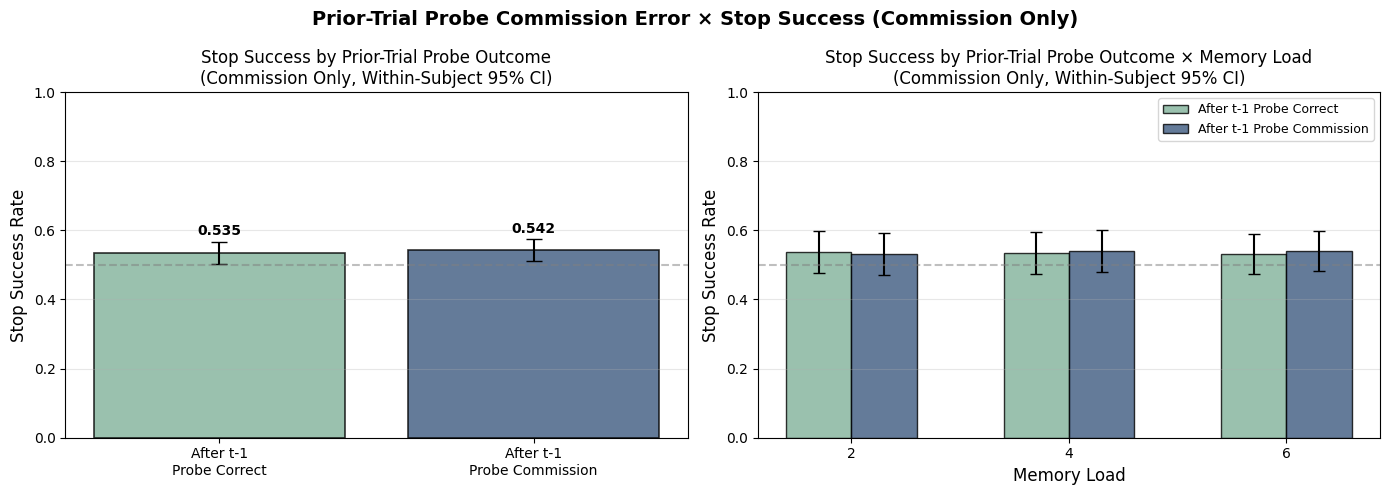


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).
Commission only: t-1 omission trials (no response) excluded.


In [15]:
# === DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT STOP SUCCESS? (COMMISSION ONLY) ===
from scipy.stats import ttest_rel

trial_data_comm = trial_wise_data_wm.copy()
trial_data_comm = trial_data_comm.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

# Lag probe accuracy and RT within each subject × block
trial_data_comm['prev_probe_correct'] = (
    trial_data_comm.groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial'].shift(1)
)
trial_data_comm['prev_probe_rt'] = (
    trial_data_comm.groupby(['participant_id', 'block_num'])['memory_recognition_rt'].shift(1)
)

# Stop success
trial_data_comm['is_stop'] = (trial_data_comm['stop_trial_SS_trial_type'] == 'stop')
trial_data_comm['stop_success'] = (
    trial_data_comm['is_stop'] & (trial_data_comm['stop_trial_correct_trial'] == 1)
).astype(float)

# Commission-only: exclude t-1 omission trials (where prev_probe_rt is NaN)
# Keep only: t-1 correct (prev_probe_correct==1) OR t-1 commission (prev_probe_correct==0 AND prev_probe_rt.notna())
stop_commission = trial_data_comm.loc[
    trial_data_comm['is_stop']
    & trial_data_comm['prev_probe_correct'].notna()
    & ((trial_data_comm['prev_probe_correct'] == 1) | trial_data_comm['prev_probe_rt'].notna())
].copy()

print("=" * 70)
print("DOES PRIOR-TRIAL PROBE COMMISSION ERROR (t-1) PREDICT STOP SUCCESS? (COMMISSION ONLY)")
print("=" * 70)

# --- Overall (collapsed across WM load) ---
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_comm = (
    stop_commission
    .groupby(['participant_id', 'prev_probe_correct'])
    .agg(stop_success_rate=('stop_success', 'mean'), n_trials=('stop_success', 'count'))
    .reset_index()
)

ac_comm = subj_comm.loc[subj_comm['prev_probe_correct'] == 1].set_index('participant_id')
ai_comm = subj_comm.loc[subj_comm['prev_probe_correct'] == 0].set_index('participant_id')
common_comm = ac_comm.index.intersection(ai_comm.index)
ac_c = ac_comm.loc[common_comm]
ai_c = ai_comm.loc[common_comm]

n_comm = len(common_comm)
print(f"Subjects with data in both conditions: {n_comm}")
print(f"\nAfter t-1 Probe CORRECT:")
print(f"  Stop success rate: M = {ac_c['stop_success_rate'].mean():.3f}, SD = {ac_c['stop_success_rate'].std():.3f}")
print(f"  Avg stop trials per subject: {ac_c['n_trials'].mean():.1f}  (range: {ac_c['n_trials'].min()}-{ac_c['n_trials'].max()})")
print(f"  Total stop trials: {ac_c['n_trials'].sum()}")

print(f"\nAfter t-1 Probe COMMISSION ERROR:")
print(f"  Stop success rate: M = {ai_c['stop_success_rate'].mean():.3f}, SD = {ai_c['stop_success_rate'].std():.3f}")
print(f"  Avg stop trials per subject: {ai_c['n_trials'].mean():.1f}  (range: {ai_c['n_trials'].min()}-{ai_c['n_trials'].max()})")
print(f"  Total stop trials: {ai_c['n_trials'].sum()}")

t_comm, p_comm = ttest_rel(ac_c['stop_success_rate'], ai_c['stop_success_rate'])
diff_comm = ac_c['stop_success_rate'].values - ai_c['stop_success_rate'].values
cohens_d_comm = diff_comm.mean() / diff_comm.std() if diff_comm.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_comm - 1}) = {t_comm:.3f}, p = {p_comm:.4f}, Cohen's d = {cohens_d_comm:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_comm) * np.log(1 + t_comm**2 / ((n_comm) - 1)) - np.log(n_comm)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\n--- t-1 Probe Commission trials per participant (Section 14: stop trials) ---")
ai_n_comm = ai_c[['n_trials']].copy()
ai_n_comm.columns = ['t-1_probe_commission_trials']
print(ai_n_comm.sort_values('t-1_probe_commission_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_comm = [2, 4, 6]
results_by_load_comm = {}

for wm_load in wm_loads_comm:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = stop_commission.loc[stop_commission['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data.groupby(['participant_id', 'prev_probe_correct'])
        .agg(stop_success_rate=('stop_success', 'mean'), n_trials=('stop_success', 'count'))
        .reset_index()
    )
    lac_comm = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
    lai_comm = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
    lc_comm = lac_comm.index.intersection(lai_comm.index)
    lac_c = lac_comm.loc[lc_comm]
    lai_c = lai_comm.loc[lc_comm]

    results_by_load_comm[wm_load] = {
        'after_correct': {'mean': lac_c['stop_success_rate'].mean(), 'std': lac_c['stop_success_rate'].std(),
                         'n': len(lc_comm), 'avg_trials': lac_c['n_trials'].mean()},
        'after_commission': {'mean': lai_c['stop_success_rate'].mean(), 'std': lai_c['stop_success_rate'].std(),
                            'n': len(lc_comm), 'avg_trials': lai_c['n_trials'].mean()},
    }

    print(f"  Subjects with both conditions: {len(lc_comm)}")
    print(f"  After t-1 Correct: M = {lac_c['stop_success_rate'].mean():.3f}")
    print(f"  After t-1 Commission: M = {lai_c['stop_success_rate'].mean():.3f}")
    if len(lc_comm) > 2:
        t_l, p_l = ttest_rel(lac_c['stop_success_rate'], lai_c['stop_success_rate'])
        d_l = lac_c['stop_success_rate'].values - lai_c['stop_success_rate'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Paired t-test: t({len(lc_comm)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc_comm)) * np.log(1 + t_l**2 / ((len(lc_comm)) - 1)) - np.log(len(lc_comm))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_comm = ['#81B29A', '#3D5A80']  # correct (green) vs commission (blue) — distinct from omission (terracotta)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-Trial Probe Commission Error × Stop Success (Commission Only)', fontsize=14, fontweight='bold')

overall_matrix_comm = pd.DataFrame({
    'After t-1 Correct': ac_c['stop_success_rate'].values,
    'After t-1 Commission': ai_c['stop_success_rate'].values,
})
ws_ci_comm = calculate_within_subject_ci(overall_matrix_comm)
means_comm = [overall_matrix_comm.iloc[:, c].mean() for c in range(2)]
cis_comm = [np.asarray(ws_ci_comm)[c] for c in range(2)]

cond_labels_comm = ['After t-1\nProbe Correct', 'After t-1\nProbe Commission']
ax1 = axes[0]
bars = ax1.bar(cond_labels_comm, means_comm, yerr=cis_comm, capsize=6, color=colors_comm, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Stop Success Rate', fontsize=12)
ax1.set_title('Stop Success by Prior-Trial Probe Outcome\n(Commission Only, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_comm, cis_comm):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[1]
x = np.arange(len(wm_loads_comm))
width = 0.3
correct_means = [results_by_load_comm[wm]['after_correct']['mean'] for wm in wm_loads_comm]
commission_means = [results_by_load_comm[wm]['after_commission']['mean'] for wm in wm_loads_comm]

# Compute within-subject CIs for each load
correct_cis = []
commission_cis = []
for wm_load in wm_loads_comm:
    load_data = stop_commission.loc[stop_commission['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data.groupby(['participant_id', 'prev_probe_correct'])
        .agg(stop_success_rate=('stop_success', 'mean'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    if len(lc) > 2:
        wm_matrix = pd.DataFrame({'correct': lac.loc[lc]['stop_success_rate'].values,
                                  'commission': lai.loc[lc]['stop_success_rate'].values})
        ws = calculate_within_subject_ci(wm_matrix)
        correct_cis.append(np.asarray(ws)[0])
        commission_cis.append(np.asarray(ws)[1])
    else:
        correct_cis.append(0)
        commission_cis.append(0)

ax2.bar(x - width/2, correct_means, width, yerr=correct_cis, capsize=4,
        label='After t-1 Probe Correct', color=colors_comm[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, commission_means, width, yerr=commission_cis, capsize=4,
        label='After t-1 Probe Commission', color=colors_comm[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Stop Success Rate', fontsize=12)
ax2.set_title('Stop Success by Prior-Trial Probe Outcome × Memory Load\n(Commission Only, Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")
print("Commission only: t-1 omission trials (no response) excluded.")

## 13. Does a Probe Omission on Trial t-1 Predict Next Probe Omission?

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict whether the participant omits on the **next** probe trial (trial t)?

- **t-1 Probe Omission → Probe trial t**: probe omission rate
- **t-1 Probe Response → Probe trial t**: probe omission rate

Only consecutive trials *within the same block* are considered. All trials have a probe; outcome = whether the participant responded on trial t.

DOES PROBE OMISSION ON TRIAL t-1 PREDICT NEXT PROBE OMISSION?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 42

After t-1 Probe OMISSION: M = 0.126, SD = 0.194
After t-1 Probe RESPONSE: M = 0.020, SD = 0.025

Paired t-test: t(41) = 3.660, p = 0.0007, Cohen's d = 0.572
  ΔBIC = 8.14, BF₁₀ = 58.46

--- t-1 Probe Omission trials per participant (Section 13: probe trials) ---
                          t-1_probe_omission_trials
participant_id                                     
69dc3f304137e723662d1a94                         73
668e88ea6a476e76e0c1993b                         53
6750f7eb7c60e2b2c22aeaea                         37
6100372e3a116cb5cb36ebea                         37
69e129bd8ad451d4d82ff01f                         28
5f9fdfd04296cb0102563f84                         27
6143af8721d1445864c4f6c8                         21
6710123050faa590f80d96e5                         19
699ec098d5e833b119bb99dc                         18
5efd32d5ebff051

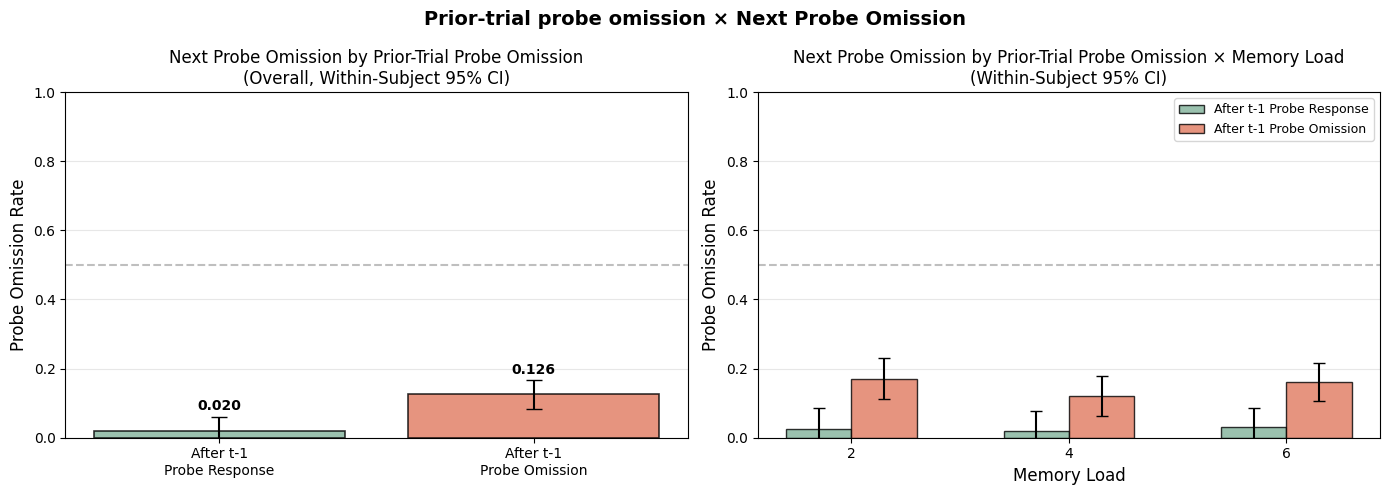


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [16]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT NEXT PROBE OMISSION? ===
from scipy.stats import ttest_rel

trial_data_next = trial_wise_data_wm.copy()
trial_data_next = trial_data_next.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_next['probe_omission'] = trial_data_next['memory_recognition_rt'].isna().astype(int)
trial_data_next['prev_probe_omission'] = (
    trial_data_next.groupby(['participant_id', 'block_num'])['probe_omission'].shift(1)
)

probe_next_data = trial_data_next.loc[trial_data_next['prev_probe_omission'].notna()].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT NEXT PROBE OMISSION?")
print("=" * 70)
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_next = (
    probe_next_data
    .groupby(['participant_id', 'prev_probe_omission'])
    .agg(probe_omission_rate=('probe_omission', 'mean'), n_trials=('probe_omission', 'count'))
    .reset_index()
)

next_after_om = subj_next.loc[subj_next['prev_probe_omission'] == 1].set_index('participant_id')
next_after_resp = subj_next.loc[subj_next['prev_probe_omission'] == 0].set_index('participant_id')
common_next = next_after_om.index.intersection(next_after_resp.index)
nao = next_after_om.loc[common_next]
nar = next_after_resp.loc[common_next]

n_next = len(common_next)
print(f"Subjects with data in both conditions: {n_next}")
print(f"\nAfter t-1 Probe OMISSION: M = {nao['probe_omission_rate'].mean():.3f}, SD = {nao['probe_omission_rate'].std():.3f}")
print(f"After t-1 Probe RESPONSE: M = {nar['probe_omission_rate'].mean():.3f}, SD = {nar['probe_omission_rate'].std():.3f}")

t_next, p_next = ttest_rel(nao['probe_omission_rate'], nar['probe_omission_rate'])
diff_next = nao['probe_omission_rate'].values - nar['probe_omission_rate'].values
cd_next = diff_next.mean() / diff_next.std() if diff_next.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_next - 1}) = {t_next:.3f}, p = {p_next:.4f}, Cohen's d = {cd_next:.3f}")
# BIC approximation (Wagenmakers, 2007)
delta_bic = (n_next) * np.log(1 + t_next**2 / ((n_next) - 1)) - np.log(n_next)
bf10 = np.exp(delta_bic / 2)
print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\n--- t-1 Probe Omission trials per participant (Section 13: probe trials) ---")
nao_n = nao[['n_trials']].copy()
nao_n.columns = ['t-1_probe_omission_trials']
print(nao_n.sort_values('t-1_probe_omission_trials', ascending=False).to_string())

print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_next = [2, 4, 6]
results_by_load_next = {}

for wm_load in wm_loads_next:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = probe_next_data.loc[probe_next_data['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data.groupby(['participant_id', 'prev_probe_omission'])
        .agg(probe_omission_rate=('probe_omission', 'mean'), n_trials=('probe_omission', 'count'))
        .reset_index()
    )
    loc = load_subj.loc[load_subj['prev_probe_omission'] == 1].set_index('participant_id')
    lorc = load_subj.loc[load_subj['prev_probe_omission'] == 0].set_index('participant_id')
    lc_next = loc.index.intersection(lorc.index)
    loc_c = loc.loc[lc_next]
    lorc_c = lorc.loc[lc_next]

    results_by_load_next[wm_load] = {
        'after_omission': {'mean': loc_c['probe_omission_rate'].mean(), 'ci': 0},
        'after_response': {'mean': lorc_c['probe_omission_rate'].mean(), 'ci': 0},
    }

    if len(lc_next) > 2:
        wm_matrix = pd.DataFrame({
            'omission': loc_c['probe_omission_rate'].values,
            'response': lorc_c['probe_omission_rate'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_next[wm_load]['after_omission']['ci'] = np.asarray(ws_ci_wm)[0]
        results_by_load_next[wm_load]['after_response']['ci'] = np.asarray(ws_ci_wm)[1]
        t_l, p_l = ttest_rel(loc_c['probe_omission_rate'], lorc_c['probe_omission_rate'])
        d_l = loc_c['probe_omission_rate'].values - lorc_c['probe_omission_rate'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc_next)}")
        print(f"  After t-1 Omission: M = {loc_c['probe_omission_rate'].mean():.3f}")
        print(f"  After t-1 Response: M = {lorc_c['probe_omission_rate'].mean():.3f}")
        print(f"  Paired t-test: t({len(lc_next)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
        # BIC approximation (Wagenmakers, 2007)
        delta_bic = (len(lc_next)) * np.log(1 + t_l**2 / ((len(lc_next)) - 1)) - np.log(len(lc_next))
        bf10 = np.exp(delta_bic / 2)
        print(f"  ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_next = ['#81B29A', '#E07A5F']  # response (left) vs omission (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe omission × Next Probe Omission', fontsize=14, fontweight='bold')

overall_matrix_next = pd.DataFrame({
    't-1 Response': nar['probe_omission_rate'].values,
    't-1 Omission': nao['probe_omission_rate'].values,
})
ws_ci_next = calculate_within_subject_ci(overall_matrix_next)
means_next = [overall_matrix_next.iloc[:, c].mean() for c in range(2)]
cis_next = [np.asarray(ws_ci_next)[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Response', 'After t-1\nProbe Omission']
ax1 = axes[0]
bars = ax1.bar(cond_labels, means_next, yerr=cis_next, capsize=6, color=colors_next, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Probe Omission Rate', fontsize=12)
ax1.set_title('Next Probe Omission by Prior-Trial Probe Omission\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_next, cis_next):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[1]
x = np.arange(len(wm_loads_next))
width = 0.3
omission_means = [results_by_load_next[wm]['after_omission']['mean'] for wm in wm_loads_next]
response_means = [results_by_load_next[wm]['after_response']['mean'] for wm in wm_loads_next]
omission_cis = [results_by_load_next[wm]['after_omission']['ci'] for wm in wm_loads_next]
response_cis = [results_by_load_next[wm]['after_response']['ci'] for wm in wm_loads_next]

ax2.bar(x - width/2, response_means, width, yerr=response_cis, capsize=4,
        label='After t-1 Probe Response', color=colors_next[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, omission_means, width, yerr=omission_cis, capsize=4,
        label='After t-1 Probe Omission', color=colors_next[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Probe Omission Rate', fontsize=12)
ax2.set_title('Next Probe Omission by Prior-Trial Probe Omission × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['2', '4', '6'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 15. Does a Probe Omission on Trial t-1 Predict Probe RT?

> ✅ **Omission-specific:** prior-trial group is omission (no response) vs. response present.

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict **probe RT** on trial t?

- **t-1 Probe Omission → probe trial t**: mean probe RT (ms)
- **t-1 Probe Response → probe trial t**: mean probe RT (ms)

Only consecutive trials *within the same block* are considered. Only trials where the participant responded to the probe on trial t are included (omissions on trial t are excluded). Within-subject 95% CIs (Cousineau-Morey).

In [17]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT PROBE RT? ===
from scipy.stats import ttest_rel

trial_data_om_prt = trial_wise_data_wm.copy()
trial_data_om_prt = trial_data_om_prt.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

# Omission flag for prior trial
trial_data_om_prt['probe_omission'] = trial_data_om_prt['memory_recognition_rt'].isna().astype(float)
trial_data_om_prt['prev_probe_omission'] = (
    trial_data_om_prt.groupby(['participant_id', 'block_num'])['probe_omission'].shift(1)
)

# Only probe trials where participant responded on trial t
probe_rt_trials = trial_data_om_prt[
    trial_data_om_prt['memory_recognition_condition'].isin(['in memory set', 'not in memory set', 'no memory set']) &
    trial_data_om_prt['prev_probe_omission'].notna() &
    trial_data_om_prt['memory_recognition_rt'].notna()
].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT PROBE RT?")
print("=" * 70)

for scope, data in [('overall', probe_rt_trials)] + [(f'wm{w}', probe_rt_trials[probe_rt_trials['memory_trial_stimLength'] == w]) for w in [2, 4, 6]]:
    a = data[data['prev_probe_omission'] == 0].groupby('participant_id')['memory_recognition_rt'].mean()
    b = data[data['prev_probe_omission'] == 1].groupby('participant_id')['memory_recognition_rt'].mean()
    common = a.index.intersection(b.index)
    a, b = a[common], b[common]
    if len(common) < 3:
        print(f"  {scope}: insufficient data (n={len(common)})")
        continue
    t, p = ttest_rel(a, b)
    import numpy as np
    d = (a - b).mean() / (a - b).std(ddof=1)
    print(f"  {scope} (n={len(common)}): after response M={a.mean():.1f} ms, after omission M={b.mean():.1f} ms | t({len(common)-1})={t:.3f}, p={p:.4f}, d={d:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = len(common) * np.log(1 + t**2 / (len(common) - 1)) - np.log(len(common))
    bf10 = np.exp(delta_bic / 2)
    print(f"    ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\nNote: Only probe trials with a response on trial t are included.")

DOES PROBE OMISSION ON TRIAL t-1 PREDICT PROBE RT?


  overall (n=42): after response M=803.9 ms, after omission M=833.7 ms | t(41)=-1.275, p=0.2095, d=-0.197
    ΔBIC = -2.10, BF₁₀ = 0.35
  wm2 (n=32): after response M=758.8 ms, after omission M=824.9 ms | t(31)=-2.284, p=0.0294, d=-0.404
    ΔBIC = 1.51, BF₁₀ = 2.13
  wm4 (n=31): after response M=800.8 ms, after omission M=814.3 ms | t(30)=-0.387, p=0.7013, d=-0.070
    ΔBIC = -3.28, BF₁₀ = 0.19
  wm6 (n=32): after response M=856.6 ms, after omission M=882.2 ms | t(31)=-0.668, p=0.5091, d=-0.118
    ΔBIC = -3.01, BF₁₀ = 0.22

Note: Only probe trials with a response on trial t are included.


## 16. Does a Probe Omission on Trial t-1 Predict Go Accuracy?

> ✅ **Omission-specific:** prior-trial group is omission (no response) vs. response present.

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict **go trial accuracy** on trial t?

- **t-1 Probe Omission → go trial t**: go accuracy
- **t-1 Probe Response → go trial t**: go accuracy

Only consecutive trials *within the same block* are considered. Within-subject 95% CIs (Cousineau-Morey).

In [18]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO ACCURACY? ===
from scipy.stats import ttest_rel
import numpy as np

trial_data_om_ga = trial_wise_data_wm.copy()
trial_data_om_ga = trial_data_om_ga.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_om_ga['probe_omission'] = trial_data_om_ga['memory_recognition_rt'].isna().astype(float)
trial_data_om_ga['prev_probe_omission'] = (
    trial_data_om_ga.groupby(['participant_id', 'block_num'])['probe_omission'].shift(1)
)
trial_data_om_ga['go_correct'] = (trial_data_om_ga['stop_trial_correct_trial'] == 1).astype(float)

go_trials = trial_data_om_ga[
    (trial_data_om_ga['stop_trial_SS_trial_type'] == 'go') &
    trial_data_om_ga['prev_probe_omission'].notna()
].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO ACCURACY?")
print("=" * 70)

for scope, data in [('overall', go_trials)] + [(f'wm{w}', go_trials[go_trials['memory_trial_stimLength'] == w]) for w in [2, 4, 6]]:
    a = data[data['prev_probe_omission'] == 0].groupby('participant_id')['go_correct'].mean()
    b = data[data['prev_probe_omission'] == 1].groupby('participant_id')['go_correct'].mean()
    common = a.index.intersection(b.index)
    a, b = a[common], b[common]
    if len(common) < 3:
        print(f"  {scope}: insufficient data (n={len(common)})")
        continue
    t, p = ttest_rel(a, b)
    d = (a - b).mean() / (a - b).std(ddof=1)
    print(f"  {scope} (n={len(common)}): after response M={a.mean():.3f}, after omission M={b.mean():.3f} | t({len(common)-1})={t:.3f}, p={p:.4f}, d={d:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = len(common) * np.log(1 + t**2 / (len(common) - 1)) - np.log(len(common))
    bf10 = np.exp(delta_bic / 2)
    print(f"    ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")

DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO ACCURACY?
  overall (n=37): after response M=0.912, after omission M=0.832 | t(36)=1.770, p=0.0851, d=0.291
    ΔBIC = -0.52, BF₁₀ = 0.77
  wm2 (n=27): after response M=0.897, after omission M=0.852 | t(26)=1.004, p=0.3248, d=0.193
    ΔBIC = -2.27, BF₁₀ = 0.32
  wm4 (n=27): after response M=0.923, after omission M=0.823 | t(26)=1.596, p=0.1225, d=0.307
    ΔBIC = -0.77, BF₁₀ = 0.68
  wm6 (n=28): after response M=0.916, after omission M=0.830 | t(27)=1.462, p=0.1552, d=0.276
    ΔBIC = -1.20, BF₁₀ = 0.55


## 17. Does a Probe Omission on Trial t-1 Predict Next Probe Commission Rate?

> ✅ **Omission-specific:** prior-trial group is omission (no response) vs. response present.

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict the **commission error rate** on the next probe trial?

- **t-1 Probe Omission → probe trial t**: commission rate (incorrect response with RT present)
- **t-1 Probe Response → probe trial t**: commission rate

Only consecutive trials *within the same block* are considered. Within-subject 95% CIs (Cousineau-Morey).

In [19]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT NEXT PROBE COMMISSION RATE? ===
from scipy.stats import ttest_rel
import numpy as np

trial_data_om_nc = trial_wise_data_wm.copy()
trial_data_om_nc = trial_data_om_nc.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_om_nc['probe_omission'] = trial_data_om_nc['memory_recognition_rt'].isna().astype(float)
trial_data_om_nc['prev_probe_omission'] = (
    trial_data_om_nc.groupby(['participant_id', 'block_num'])['probe_omission'].shift(1)
)
# Commission on current trial: responded but wrong
trial_data_om_nc['probe_commission'] = (
    (trial_data_om_nc['memory_recognition_correct_trial'] == 0) &
    trial_data_om_nc['memory_recognition_rt'].notna()
).astype(float)

probe_trials = trial_data_om_nc[
    trial_data_om_nc['memory_recognition_condition'].isin(['in memory set', 'not in memory set', 'no memory set']) &
    trial_data_om_nc['prev_probe_omission'].notna()
].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT NEXT PROBE COMMISSION RATE?")
print("=" * 70)

for scope, data in [('overall', probe_trials)] + [(f'wm{w}', probe_trials[probe_trials['memory_trial_stimLength'] == w]) for w in [2, 4, 6]]:
    a = data[data['prev_probe_omission'] == 0].groupby('participant_id')['probe_commission'].mean()
    b = data[data['prev_probe_omission'] == 1].groupby('participant_id')['probe_commission'].mean()
    common = a.index.intersection(b.index)
    a, b = a[common], b[common]
    if len(common) < 3:
        print(f"  {scope}: insufficient data (n={len(common)})")
        continue
    t, p = ttest_rel(a, b)
    d = (a - b).mean() / (a - b).std(ddof=1)
    print(f"  {scope} (n={len(common)}): after response M={a.mean():.3f}, after omission M={b.mean():.3f} | t({len(common)-1})={t:.3f}, p={p:.4f}, d={d:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = len(common) * np.log(1 + t**2 / (len(common) - 1)) - np.log(len(common))
    bf10 = np.exp(delta_bic / 2)
    print(f"    ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")

DOES PROBE OMISSION ON TRIAL t-1 PREDICT NEXT PROBE COMMISSION RATE?
  overall (n=42): after response M=0.114, after omission M=0.199 | t(41)=-2.198, p=0.0337, d=-0.339
    ΔBIC = 0.94, BF₁₀ = 1.60
  wm2 (n=32): after response M=0.089, after omission M=0.057 | t(31)=1.490, p=0.1462, d=0.263
    ΔBIC = -1.25, BF₁₀ = 0.53
  wm4 (n=31): after response M=0.103, after omission M=0.184 | t(30)=-1.884, p=0.0693, d=-0.338
    ΔBIC = 0.03, BF₁₀ = 1.02
  wm6 (n=32): after response M=0.180, after omission M=0.312 | t(31)=-2.721, p=0.0106, d=-0.481
    ΔBIC = 3.39, BF₁₀ = 5.44


## 18. Does Prior-Trial Probe Commission Error Predict Probe RT? (Commission Only)

> ✅ **Commission-specific:** prior-trial group is commission error vs. correct (omissions excluded).

Sequential dependency analysis: does a probe commission error (incorrect response, RT present) on trial t-1 predict **probe RT** on trial t?

- **t-1 Commission error → probe trial t**: mean probe RT (ms)
- **t-1 Correct probe → probe trial t**: mean probe RT (ms)

Omission trials on trial t-1 are excluded. Only probe trials where the participant responded on trial t are included. Only consecutive trials *within the same block* are considered.

In [20]:
# === DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT PROBE RT? (COMMISSION ONLY) ===
from scipy.stats import ttest_rel
import numpy as np

trial_data_cp = trial_wise_data_wm.copy()
trial_data_cp = trial_data_cp.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

g = trial_data_cp.groupby(['participant_id', 'block_num'])
trial_data_cp['prev_probe_correct']    = g['memory_recognition_correct_trial'].shift(1)
trial_data_cp['prev_probe_rt']         = g['memory_recognition_rt'].shift(1)
trial_data_cp['prev_probe_commission'] = (
    (trial_data_cp['prev_probe_correct'] == 0) & trial_data_cp['prev_probe_rt'].notna()
).astype(float)
# Correct group: prev correct AND responded (exclude omissions)
trial_data_cp['prev_probe_correct_clean'] = (
    (trial_data_cp['prev_probe_correct'] == 1) & trial_data_cp['prev_probe_rt'].notna()
).astype(float)

probe_trials_cp = trial_data_cp[
    trial_data_cp['memory_recognition_condition'].isin(['in memory set', 'not in memory set', 'no memory set']) &
    trial_data_cp['memory_recognition_rt'].notna()
].copy()

print("=" * 70)
print("DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT PROBE RT? (COMMISSION ONLY)")
print("=" * 70)

for scope, data in [('overall', probe_trials_cp)] + [(f'wm{w}', probe_trials_cp[probe_trials_cp['memory_trial_stimLength'] == w]) for w in [2, 4, 6]]:
    a = data[data['prev_probe_correct_clean'] == 1].groupby('participant_id')['memory_recognition_rt'].mean()
    b = data[data['prev_probe_commission'] == 1].groupby('participant_id')['memory_recognition_rt'].mean()
    common = a.index.intersection(b.index)
    a, b = a[common], b[common]
    if len(common) < 3:
        print(f"  {scope}: insufficient data (n={len(common)})")
        continue
    t, p = ttest_rel(a, b)
    d = (a - b).mean() / (a - b).std(ddof=1)
    print(f"  {scope} (n={len(common)}): after correct M={a.mean():.1f} ms, after commission M={b.mean():.1f} ms | t({len(common)-1})={t:.3f}, p={p:.4f}, d={d:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = len(common) * np.log(1 + t**2 / (len(common) - 1)) - np.log(len(common))
    bf10 = np.exp(delta_bic / 2)
    print(f"    ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\nNote: t-1 omission trials excluded; only trials where participant responded on trial t included.")

DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT PROBE RT? (COMMISSION ONLY)
  overall (n=50): after correct M=785.0 ms, after commission M=787.6 ms | t(49)=-0.366, p=0.7162, d=-0.052
    ΔBIC = -3.78, BF₁₀ = 0.15
  wm2 (n=49): after correct M=745.0 ms, after commission M=748.3 ms | t(48)=-0.362, p=0.7188, d=-0.052
    ΔBIC = -3.76, BF₁₀ = 0.15
  wm4 (n=50): after correct M=777.8 ms, after commission M=781.2 ms | t(49)=-0.292, p=0.7715, d=-0.041
    ΔBIC = -3.83, BF₁₀ = 0.15
  wm6 (n=50): after correct M=835.8 ms, after commission M=836.8 ms | t(49)=-0.083, p=0.9343, d=-0.012
    ΔBIC = -3.91, BF₁₀ = 0.14

Note: t-1 omission trials excluded; only trials where participant responded on trial t included.


## 19. Does Prior-Trial Probe Commission Error Predict Go RT? (Commission Only)

> ✅ **Commission-specific:** prior-trial group is commission error vs. correct (omissions excluded).

Sequential dependency: does a probe commission error on trial t-1 predict **go trial RT** on trial t?

Only consecutive trials *within the same block* are considered. t-1 omission trials are excluded.

In [21]:
# === DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT GO RT? (COMMISSION ONLY) ===
from scipy.stats import ttest_rel
import numpy as np

trial_data_cg = trial_wise_data_wm.copy()
trial_data_cg = trial_data_cg.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

g = trial_data_cg.groupby(['participant_id', 'block_num'])
trial_data_cg['prev_probe_correct'] = g['memory_recognition_correct_trial'].shift(1)
trial_data_cg['prev_probe_rt']      = g['memory_recognition_rt'].shift(1)
trial_data_cg['prev_commission'] = (
    (trial_data_cg['prev_probe_correct'] == 0) & trial_data_cg['prev_probe_rt'].notna()
).astype(float)
trial_data_cg['prev_correct_clean'] = (
    (trial_data_cg['prev_probe_correct'] == 1) & trial_data_cg['prev_probe_rt'].notna()
).astype(float)

go_trials_cg = trial_data_cg[
    (trial_data_cg['stop_trial_SS_trial_type'] == 'go') &
    trial_data_cg['stop_trial_rt'].notna()
].copy()

print("=" * 70)
print("DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT GO RT? (COMMISSION ONLY)")
print("=" * 70)

for scope, data in [('overall', go_trials_cg)] + [(f'wm{w}', go_trials_cg[go_trials_cg['memory_trial_stimLength'] == w]) for w in [2, 4, 6]]:
    a = data[data['prev_correct_clean'] == 1].groupby('participant_id')['stop_trial_rt'].mean()
    b = data[data['prev_commission'] == 1].groupby('participant_id')['stop_trial_rt'].mean()
    common = a.index.intersection(b.index)
    a, b = a[common], b[common]
    if len(common) < 3:
        print(f"  {scope}: insufficient data (n={len(common)})")
        continue
    t, p = ttest_rel(a, b)
    d = (a - b).mean() / (a - b).std(ddof=1)
    print(f"  {scope} (n={len(common)}): after correct M={a.mean():.1f} ms, after commission M={b.mean():.1f} ms | t({len(common)-1})={t:.3f}, p={p:.4f}, d={d:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = len(common) * np.log(1 + t**2 / (len(common) - 1)) - np.log(len(common))
    bf10 = np.exp(delta_bic / 2)
    print(f"    ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")

DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT GO RT? (COMMISSION ONLY)
  overall (n=50): after correct M=764.8 ms, after commission M=767.6 ms | t(49)=-0.590, p=0.5580, d=-0.083
    ΔBIC = -3.56, BF₁₀ = 0.17
  wm2 (n=49): after correct M=748.3 ms, after commission M=751.1 ms | t(48)=-0.283, p=0.7782, d=-0.040
    ΔBIC = -3.81, BF₁₀ = 0.15


  wm4 (n=50): after correct M=765.8 ms, after commission M=768.4 ms | t(49)=-0.265, p=0.7920, d=-0.037
    ΔBIC = -3.84, BF₁₀ = 0.15
  wm6 (n=48): after correct M=778.4 ms, after commission M=779.0 ms | t(47)=-0.073, p=0.9422, d=-0.011
    ΔBIC = -3.87, BF₁₀ = 0.14


## 20. Does Prior-Trial Probe Commission Error Predict SSD? (Commission Only)

> ✅ **Commission-specific:** prior-trial group is commission error vs. correct (omissions excluded).

Sequential dependency: does a probe commission error on trial t-1 predict **SSD** on the following stop trial?

Only consecutive trials *within the same block* are considered. t-1 omission trials are excluded.

In [22]:
# === DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT SSD? (COMMISSION ONLY) ===
from scipy.stats import ttest_rel
import numpy as np

trial_data_cs = trial_wise_data_wm.copy()
trial_data_cs = trial_data_cs.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

g = trial_data_cs.groupby(['participant_id', 'block_num'])
trial_data_cs['prev_probe_correct'] = g['memory_recognition_correct_trial'].shift(1)
trial_data_cs['prev_probe_rt']      = g['memory_recognition_rt'].shift(1)
trial_data_cs['prev_commission'] = (
    (trial_data_cs['prev_probe_correct'] == 0) & trial_data_cs['prev_probe_rt'].notna()
).astype(float)
trial_data_cs['prev_correct_clean'] = (
    (trial_data_cs['prev_probe_correct'] == 1) & trial_data_cs['prev_probe_rt'].notna()
).astype(float)

stop_trials_cs = trial_data_cs[
    trial_data_cs['is_stop'] if 'is_stop' in trial_data_cs.columns else
    (trial_data_cs['stop_trial_SS_trial_type'] == 'stop')
].copy()
stop_trials_cs = stop_trials_cs[stop_trials_cs['stop_trial_SSD'].notna()]

print("=" * 70)
print("DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT SSD? (COMMISSION ONLY)")
print("=" * 70)

for scope, data in [('overall', stop_trials_cs)] + [(f'wm{w}', stop_trials_cs[stop_trials_cs['memory_trial_stimLength'] == w]) for w in [2, 4, 6]]:
    a = data[data['prev_correct_clean'] == 1].groupby('participant_id')['stop_trial_SSD'].mean()
    b = data[data['prev_commission'] == 1].groupby('participant_id')['stop_trial_SSD'].mean()
    common = a.index.intersection(b.index)
    a, b = a[common], b[common]
    if len(common) < 3:
        print(f"  {scope}: insufficient data (n={len(common)})")
        continue
    t, p = ttest_rel(a, b)
    d = (a - b).mean() / (a - b).std(ddof=1)
    print(f"  {scope} (n={len(common)}): after correct M={a.mean():.1f} ms, after commission M={b.mean():.1f} ms | t({len(common)-1})={t:.3f}, p={p:.4f}, d={d:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = len(common) * np.log(1 + t**2 / (len(common) - 1)) - np.log(len(common))
    bf10 = np.exp(delta_bic / 2)
    print(f"    ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")

DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT SSD? (COMMISSION ONLY)
  overall (n=50): after correct M=495.6 ms, after commission M=490.3 ms | t(49)=1.271, p=0.2098, d=0.180
    ΔBIC = -2.29, BF₁₀ = 0.32
  wm2 (n=49): after correct M=482.6 ms, after commission M=475.5 ms | t(48)=1.001, p=0.3220, d=0.143
    ΔBIC = -2.88, BF₁₀ = 0.24
  wm4 (n=48): after correct M=491.8 ms, after commission M=487.0 ms | t(47)=0.627, p=0.5335, d=0.091
    ΔBIC = -3.47, BF₁₀ = 0.18
  wm6 (n=48): after correct M=501.4 ms, after commission M=497.8 ms | t(47)=0.548, p=0.5860, d=0.079
    ΔBIC = -3.57, BF₁₀ = 0.17


## 21. Does Prior-Trial Probe Commission Error Predict Go Accuracy? (Commission Only)

> ✅ **Commission-specific:** prior-trial group is commission error vs. correct (omissions excluded).

Sequential dependency: does a probe commission error on trial t-1 predict **go trial accuracy** on trial t?

Only consecutive trials *within the same block* are considered. t-1 omission trials are excluded.

In [23]:
# === DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT GO ACCURACY? (COMMISSION ONLY) ===
from scipy.stats import ttest_rel
import numpy as np

trial_data_cga = trial_wise_data_wm.copy()
trial_data_cga = trial_data_cga.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

g = trial_data_cga.groupby(['participant_id', 'block_num'])
trial_data_cga['prev_probe_correct'] = g['memory_recognition_correct_trial'].shift(1)
trial_data_cga['prev_probe_rt']      = g['memory_recognition_rt'].shift(1)
trial_data_cga['prev_commission'] = (
    (trial_data_cga['prev_probe_correct'] == 0) & trial_data_cga['prev_probe_rt'].notna()
).astype(float)
trial_data_cga['prev_correct_clean'] = (
    (trial_data_cga['prev_probe_correct'] == 1) & trial_data_cga['prev_probe_rt'].notna()
).astype(float)
trial_data_cga['go_correct'] = (trial_data_cga['stop_trial_correct_trial'] == 1).astype(float)

go_trials_cga = trial_data_cga[trial_data_cga['stop_trial_SS_trial_type'] == 'go'].copy()

print("=" * 70)
print("DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT GO ACCURACY? (COMMISSION ONLY)")
print("=" * 70)

for scope, data in [('overall', go_trials_cga)] + [(f'wm{w}', go_trials_cga[go_trials_cga['memory_trial_stimLength'] == w]) for w in [2, 4, 6]]:
    a = data[data['prev_correct_clean'] == 1].groupby('participant_id')['go_correct'].mean()
    b = data[data['prev_commission'] == 1].groupby('participant_id')['go_correct'].mean()
    common = a.index.intersection(b.index)
    a, b = a[common], b[common]
    if len(common) < 3:
        print(f"  {scope}: insufficient data (n={len(common)})")
        continue
    t, p = ttest_rel(a, b)
    d = (a - b).mean() / (a - b).std(ddof=1)
    print(f"  {scope} (n={len(common)}): after correct M={a.mean():.3f}, after commission M={b.mean():.3f} | t({len(common)-1})={t:.3f}, p={p:.4f}, d={d:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = len(common) * np.log(1 + t**2 / (len(common) - 1)) - np.log(len(common))
    bf10 = np.exp(delta_bic / 2)
    print(f"    ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")

DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT GO ACCURACY? (COMMISSION ONLY)
  overall (n=50): after correct M=0.925, after commission M=0.916 | t(49)=1.008, p=0.3183, d=0.143
    ΔBIC = -2.89, BF₁₀ = 0.24
  wm2 (n=49): after correct M=0.918, after commission M=0.921 | t(48)=-0.253, p=0.8014, d=-0.036
    ΔBIC = -3.83, BF₁₀ = 0.15
  wm4 (n=50): after correct M=0.927, after commission M=0.915 | t(49)=0.964, p=0.3396, d=0.136
    ΔBIC = -2.97, BF₁₀ = 0.23
  wm6 (n=48): after correct M=0.928, after commission M=0.922 | t(47)=0.496, p=0.6224, d=0.072
    ΔBIC = -3.62, BF₁₀ = 0.16


## 22. Does Prior-Trial Probe Commission Error Predict Go Omission Rate? (Commission Only)

> ✅ **Commission-specific:** prior-trial group is commission error vs. correct (omissions excluded).

Sequential dependency: does a probe commission error on trial t-1 predict the **go omission rate** (no response to the go signal) on trial t?

Only consecutive trials *within the same block* are considered. t-1 omission trials are excluded.

In [24]:
# === DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT GO OMISSION RATE? (COMMISSION ONLY) ===
from scipy.stats import ttest_rel
import numpy as np

trial_data_cgo = trial_wise_data_wm.copy()
trial_data_cgo = trial_data_cgo.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

g = trial_data_cgo.groupby(['participant_id', 'block_num'])
trial_data_cgo['prev_probe_correct'] = g['memory_recognition_correct_trial'].shift(1)
trial_data_cgo['prev_probe_rt']      = g['memory_recognition_rt'].shift(1)
trial_data_cgo['prev_commission'] = (
    (trial_data_cgo['prev_probe_correct'] == 0) & trial_data_cgo['prev_probe_rt'].notna()
).astype(float)
trial_data_cgo['prev_correct_clean'] = (
    (trial_data_cgo['prev_probe_correct'] == 1) & trial_data_cgo['prev_probe_rt'].notna()
).astype(float)
trial_data_cgo['go_omission'] = (
    (trial_data_cgo['stop_trial_SS_trial_type'] == 'go') &
    trial_data_cgo['stop_trial_rt'].isna()
).astype(float)

go_trials_cgo = trial_data_cgo[trial_data_cgo['stop_trial_SS_trial_type'] == 'go'].copy()

print("=" * 70)
print("DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT GO OMISSION RATE? (COMMISSION ONLY)")
print("=" * 70)

for scope, data in [('overall', go_trials_cgo)] + [(f'wm{w}', go_trials_cgo[go_trials_cgo['memory_trial_stimLength'] == w]) for w in [2, 4, 6]]:
    a = data[data['prev_correct_clean'] == 1].groupby('participant_id')['go_omission'].mean()
    b = data[data['prev_commission'] == 1].groupby('participant_id')['go_omission'].mean()
    common = a.index.intersection(b.index)
    a, b = a[common], b[common]
    if len(common) < 3:
        print(f"  {scope}: insufficient data (n={len(common)})")
        continue
    t, p = ttest_rel(a, b)
    d = (a - b).mean() / (a - b).std(ddof=1)
    print(f"  {scope} (n={len(common)}): after correct M={a.mean():.3f}, after commission M={b.mean():.3f} | t({len(common)-1})={t:.3f}, p={p:.4f}, d={d:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = len(common) * np.log(1 + t**2 / (len(common) - 1)) - np.log(len(common))
    bf10 = np.exp(delta_bic / 2)
    print(f"    ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\nNote: t-1 omission trials excluded from the prior-trial IV.")

DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT GO OMISSION RATE? (COMMISSION ONLY)
  overall (n=50): after correct M=0.027, after commission M=0.034 | t(49)=-1.342, p=0.1858, d=-0.190
    ΔBIC = -2.11, BF₁₀ = 0.35
  wm2 (n=49): after correct M=0.030, after commission M=0.025 | t(48)=0.614, p=0.5422, d=0.088
    ΔBIC = -3.51, BF₁₀ = 0.17
  wm4 (n=50): after correct M=0.027, after commission M=0.037 | t(49)=-1.016, p=0.3145, d=-0.144
    ΔBIC = -2.87, BF₁₀ = 0.24
  wm6 (n=48): after correct M=0.027, after commission M=0.034 | t(47)=-0.832, p=0.4098, d=-0.120
    ΔBIC = -3.17, BF₁₀ = 0.20

Note: t-1 omission trials excluded from the prior-trial IV.


## 23. Does Prior-Trial Probe Commission Error Predict Next Probe Omission Rate? (Commission Only)

> ✅ **Commission-specific:** prior-trial group is commission error vs. correct (omissions excluded).

Sequential dependency: does a probe commission error on trial t-1 predict the **probe omission rate** (no response to the probe) on the next probe trial?

Only consecutive trials *within the same block* are considered. t-1 omission trials are excluded.

In [25]:
# === DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT NEXT PROBE OMISSION RATE? (COMMISSION ONLY) ===
from scipy.stats import ttest_rel
import numpy as np

trial_data_cno = trial_wise_data_wm.copy()
trial_data_cno = trial_data_cno.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

g = trial_data_cno.groupby(['participant_id', 'block_num'])
trial_data_cno['prev_probe_correct'] = g['memory_recognition_correct_trial'].shift(1)
trial_data_cno['prev_probe_rt']      = g['memory_recognition_rt'].shift(1)
trial_data_cno['prev_commission'] = (
    (trial_data_cno['prev_probe_correct'] == 0) & trial_data_cno['prev_probe_rt'].notna()
).astype(float)
trial_data_cno['prev_correct_clean'] = (
    (trial_data_cno['prev_probe_correct'] == 1) & trial_data_cno['prev_probe_rt'].notna()
).astype(float)
trial_data_cno['probe_omission'] = trial_data_cno['memory_recognition_rt'].isna().astype(float)

probe_trials_cno = trial_data_cno[
    trial_data_cno['memory_recognition_condition'].isin(['in memory set', 'not in memory set', 'no memory set'])
].copy()

print("=" * 70)
print("DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT NEXT PROBE OMISSION RATE? (COMMISSION ONLY)")
print("=" * 70)

for scope, data in [('overall', probe_trials_cno)] + [(f'wm{w}', probe_trials_cno[probe_trials_cno['memory_trial_stimLength'] == w]) for w in [2, 4, 6]]:
    a = data[data['prev_correct_clean'] == 1].groupby('participant_id')['probe_omission'].mean()
    b = data[data['prev_commission'] == 1].groupby('participant_id')['probe_omission'].mean()
    common = a.index.intersection(b.index)
    a, b = a[common], b[common]
    if len(common) < 3:
        print(f"  {scope}: insufficient data (n={len(common)})")
        continue
    t, p = ttest_rel(a, b)
    d = (a - b).mean() / (a - b).std(ddof=1)
    print(f"  {scope} (n={len(common)}): after correct M={a.mean():.3f}, after commission M={b.mean():.3f} | t({len(common)-1})={t:.3f}, p={p:.4f}, d={d:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = len(common) * np.log(1 + t**2 / (len(common) - 1)) - np.log(len(common))
    bf10 = np.exp(delta_bic / 2)
    print(f"    ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")

DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT NEXT PROBE OMISSION RATE? (COMMISSION ONLY)
  overall (n=50): after correct M=0.016, after commission M=0.023 | t(49)=-1.939, p=0.0582, d=-0.274
    ΔBIC = -0.21, BF₁₀ = 0.90
  wm2 (n=49): after correct M=0.018, after commission M=0.021 | t(48)=-0.498, p=0.6205, d=-0.071
    ΔBIC = -3.64, BF₁₀ = 0.16
  wm4 (n=50): after correct M=0.012, after commission M=0.019 | t(49)=-1.539, p=0.1302, d=-0.218
    ΔBIC = -1.55, BF₁₀ = 0.46
  wm6 (n=50): after correct M=0.018, after commission M=0.027 | t(49)=-1.597, p=0.1166, d=-0.226
    ΔBIC = -1.37, BF₁₀ = 0.50


## 24. Does Prior-Trial Probe Commission Error Predict Next Probe Commission Rate? (Commission Only)

> ✅ **Commission-specific:** prior-trial group is commission error vs. correct (omissions excluded).

Sequential dependency: does a probe commission error on trial t-1 predict the **commission error rate** on the next probe trial?

Only consecutive trials *within the same block* are considered. t-1 omission trials are excluded.

In [26]:
# === DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT NEXT PROBE COMMISSION RATE? (COMMISSION ONLY) ===
from scipy.stats import ttest_rel
import numpy as np

trial_data_cnc = trial_wise_data_wm.copy()
trial_data_cnc = trial_data_cnc.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

g = trial_data_cnc.groupby(['participant_id', 'block_num'])
trial_data_cnc['prev_probe_correct'] = g['memory_recognition_correct_trial'].shift(1)
trial_data_cnc['prev_probe_rt']      = g['memory_recognition_rt'].shift(1)
trial_data_cnc['prev_commission'] = (
    (trial_data_cnc['prev_probe_correct'] == 0) & trial_data_cnc['prev_probe_rt'].notna()
).astype(float)
trial_data_cnc['prev_correct_clean'] = (
    (trial_data_cnc['prev_probe_correct'] == 1) & trial_data_cnc['prev_probe_rt'].notna()
).astype(float)
trial_data_cnc['probe_commission'] = (
    (trial_data_cnc['memory_recognition_correct_trial'] == 0) &
    trial_data_cnc['memory_recognition_rt'].notna()
).astype(float)

probe_trials_cnc = trial_data_cnc[
    trial_data_cnc['memory_recognition_condition'].isin(['in memory set', 'not in memory set', 'no memory set'])
].copy()

print("=" * 70)
print("DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT NEXT PROBE COMMISSION RATE? (COMMISSION ONLY)")
print("=" * 70)

for scope, data in [('overall', probe_trials_cnc)] + [(f'wm{w}', probe_trials_cnc[probe_trials_cnc['memory_trial_stimLength'] == w]) for w in [2, 4, 6]]:
    a = data[data['prev_correct_clean'] == 1].groupby('participant_id')['probe_commission'].mean()
    b = data[data['prev_commission'] == 1].groupby('participant_id')['probe_commission'].mean()
    common = a.index.intersection(b.index)
    a, b = a[common], b[common]
    if len(common) < 3:
        print(f"  {scope}: insufficient data (n={len(common)})")
        continue
    t, p = ttest_rel(a, b)
    d = (a - b).mean() / (a - b).std(ddof=1)
    print(f"  {scope} (n={len(common)}): after correct M={a.mean():.3f}, after commission M={b.mean():.3f} | t({len(common)-1})={t:.3f}, p={p:.4f}, d={d:.3f}")
    # BIC approximation (Wagenmakers, 2007)
    delta_bic = len(common) * np.log(1 + t**2 / (len(common) - 1)) - np.log(len(common))
    bf10 = np.exp(delta_bic / 2)
    print(f"    ΔBIC = {delta_bic:.2f}, BF₁₀ = {bf10:.2f}")
print("\nNote: t-1 omission trials excluded. A significant effect would indicate sequential error clustering or correction.")

DOES PRIOR-TRIAL PROBE COMMISSION ERROR PREDICT NEXT PROBE COMMISSION RATE? (COMMISSION ONLY)
  overall (n=50): after correct M=0.104, after commission M=0.113 | t(49)=-1.066, p=0.2916, d=-0.151
    ΔBIC = -2.77, BF₁₀ = 0.25
  wm2 (n=49): after correct M=0.068, after commission M=0.093 | t(48)=-1.832, p=0.0731, d=-0.262
    ΔBIC = -0.58, BF₁₀ = 0.75
  wm4 (n=50): after correct M=0.086, after commission M=0.087 | t(49)=-0.093, p=0.9265, d=-0.013
    ΔBIC = -3.90, BF₁₀ = 0.14
  wm6 (n=50): after correct M=0.160, after commission M=0.165 | t(49)=-0.330, p=0.7427, d=-0.047
    ΔBIC = -3.80, BF₁₀ = 0.15

Note: t-1 omission trials excluded. A significant effect would indicate sequential error clustering or correction.
